[RL-MM]  PyTorch 2.10.0+cpu  |  device=cpu

  [PPO]  90° heading change  [nav]
  ep~ 302 | MeanRet= -3735.3 | t=79s
  ep~ 602 | MeanRet= -4179.7 | t=158s
  [EVAL] R=-38996.6 suc=0.0% herr=91.6°
  ep~ 902 | MeanRet= -4344.7 | t=239s
  ep~1203 | MeanRet= -4105.1 | t=318s
  [EVAL] R=-38268.7 suc=0.0% herr=18.0°
  ep~1503 | MeanRet= -4579.6 | t=396s
  ep~1806 | MeanRet= -4004.8 | t=475s
  [EVAL] R=-41744.6 suc=0.0% herr=9.5°
  ep~2106 | MeanRet= -4155.1 | t=555s
  ep~2409 | MeanRet= -4318.4 | t=634s
  [EVAL] R=-39601.6 suc=0.0% herr=80.6°
  ep~2700 | MeanRet= -4728.7 | t=712s
  ep~3002 | MeanRet= -4358.8 | t=790s
  [EVAL] R=-40846.1 suc=0.0% herr=51.4°

  [PPO]  180° heading change  [nav]
  ep~ 304 | MeanRet= -6858.6 | t=129s
  ep~ 601 | MeanRet= -6850.0 | t=255s
  [EVAL] R=-79925.5 suc=0.0% herr=105.2°
  ep~ 900 | MeanRet= -7256.2 | t=386s
  ep~1204 | MeanRet= -7373.7 | t=513s
  [EVAL] R=-71451.6 suc=0.0% herr=98.2°
  ep~1505 | MeanRet= -7038.2 | t=642s
  ep~1800 | MeanRet= -7104.8 | t=76

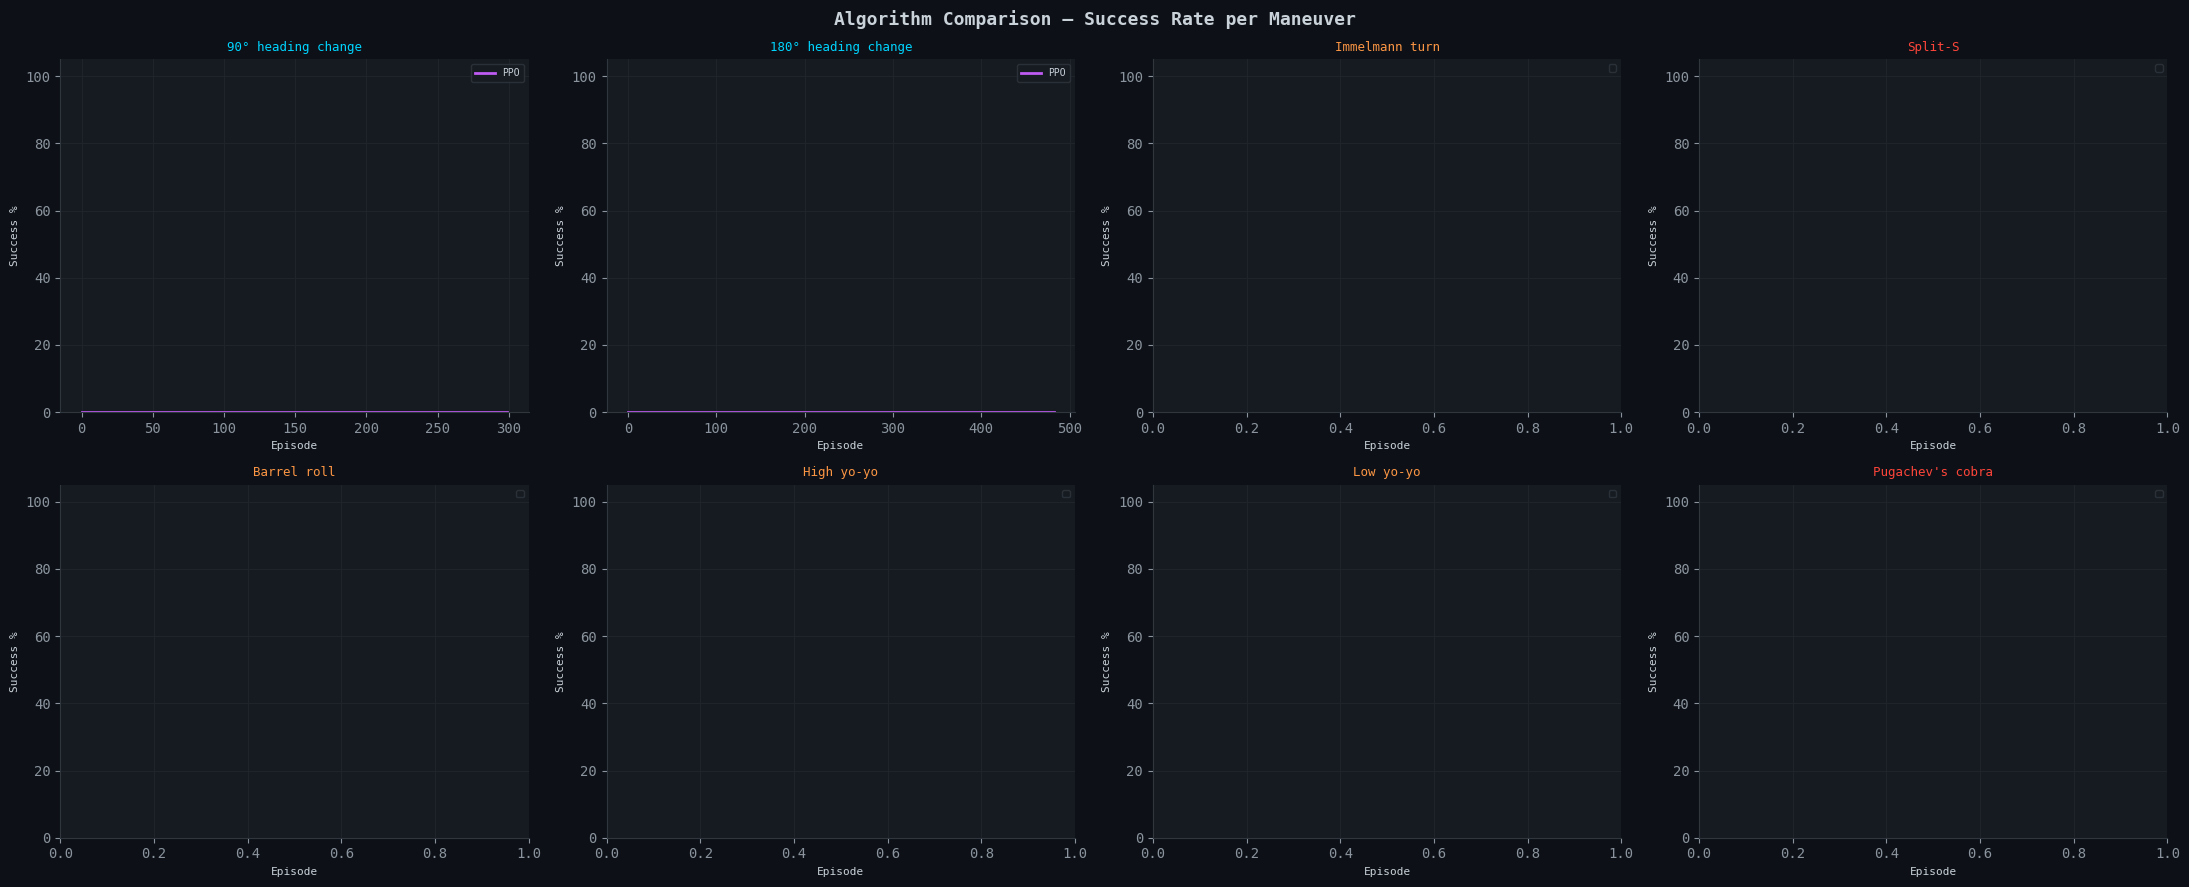

[Saved] algo_comparison.png


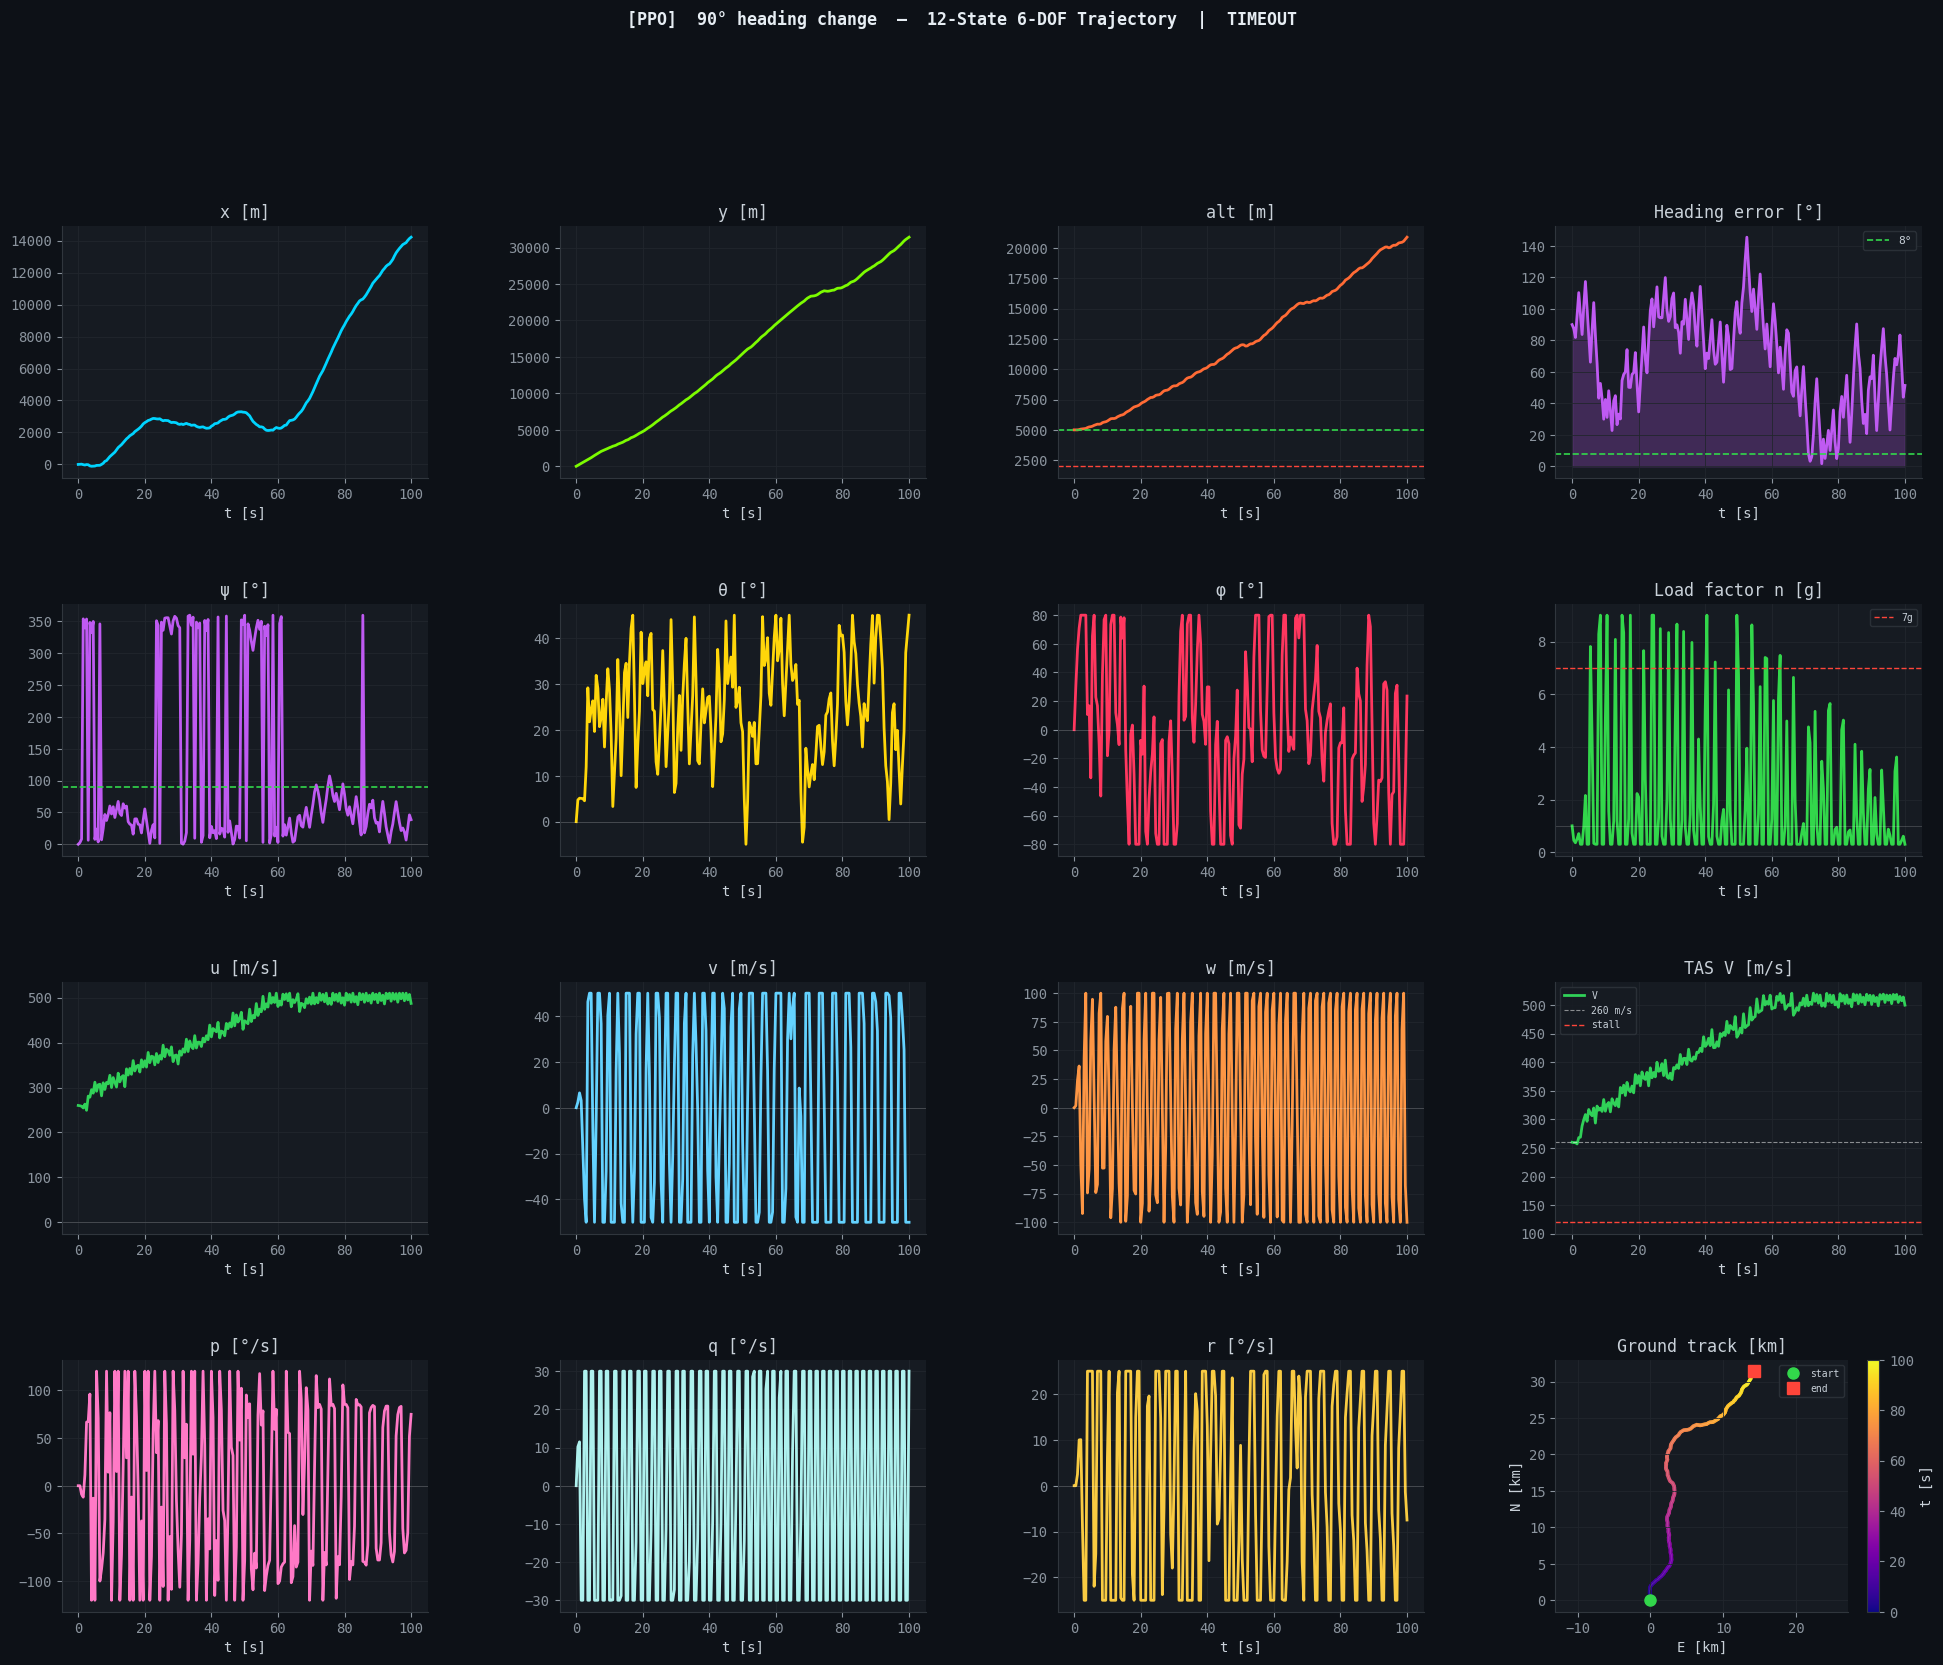

[Saved] PPO_90°_heading_change_12state.png


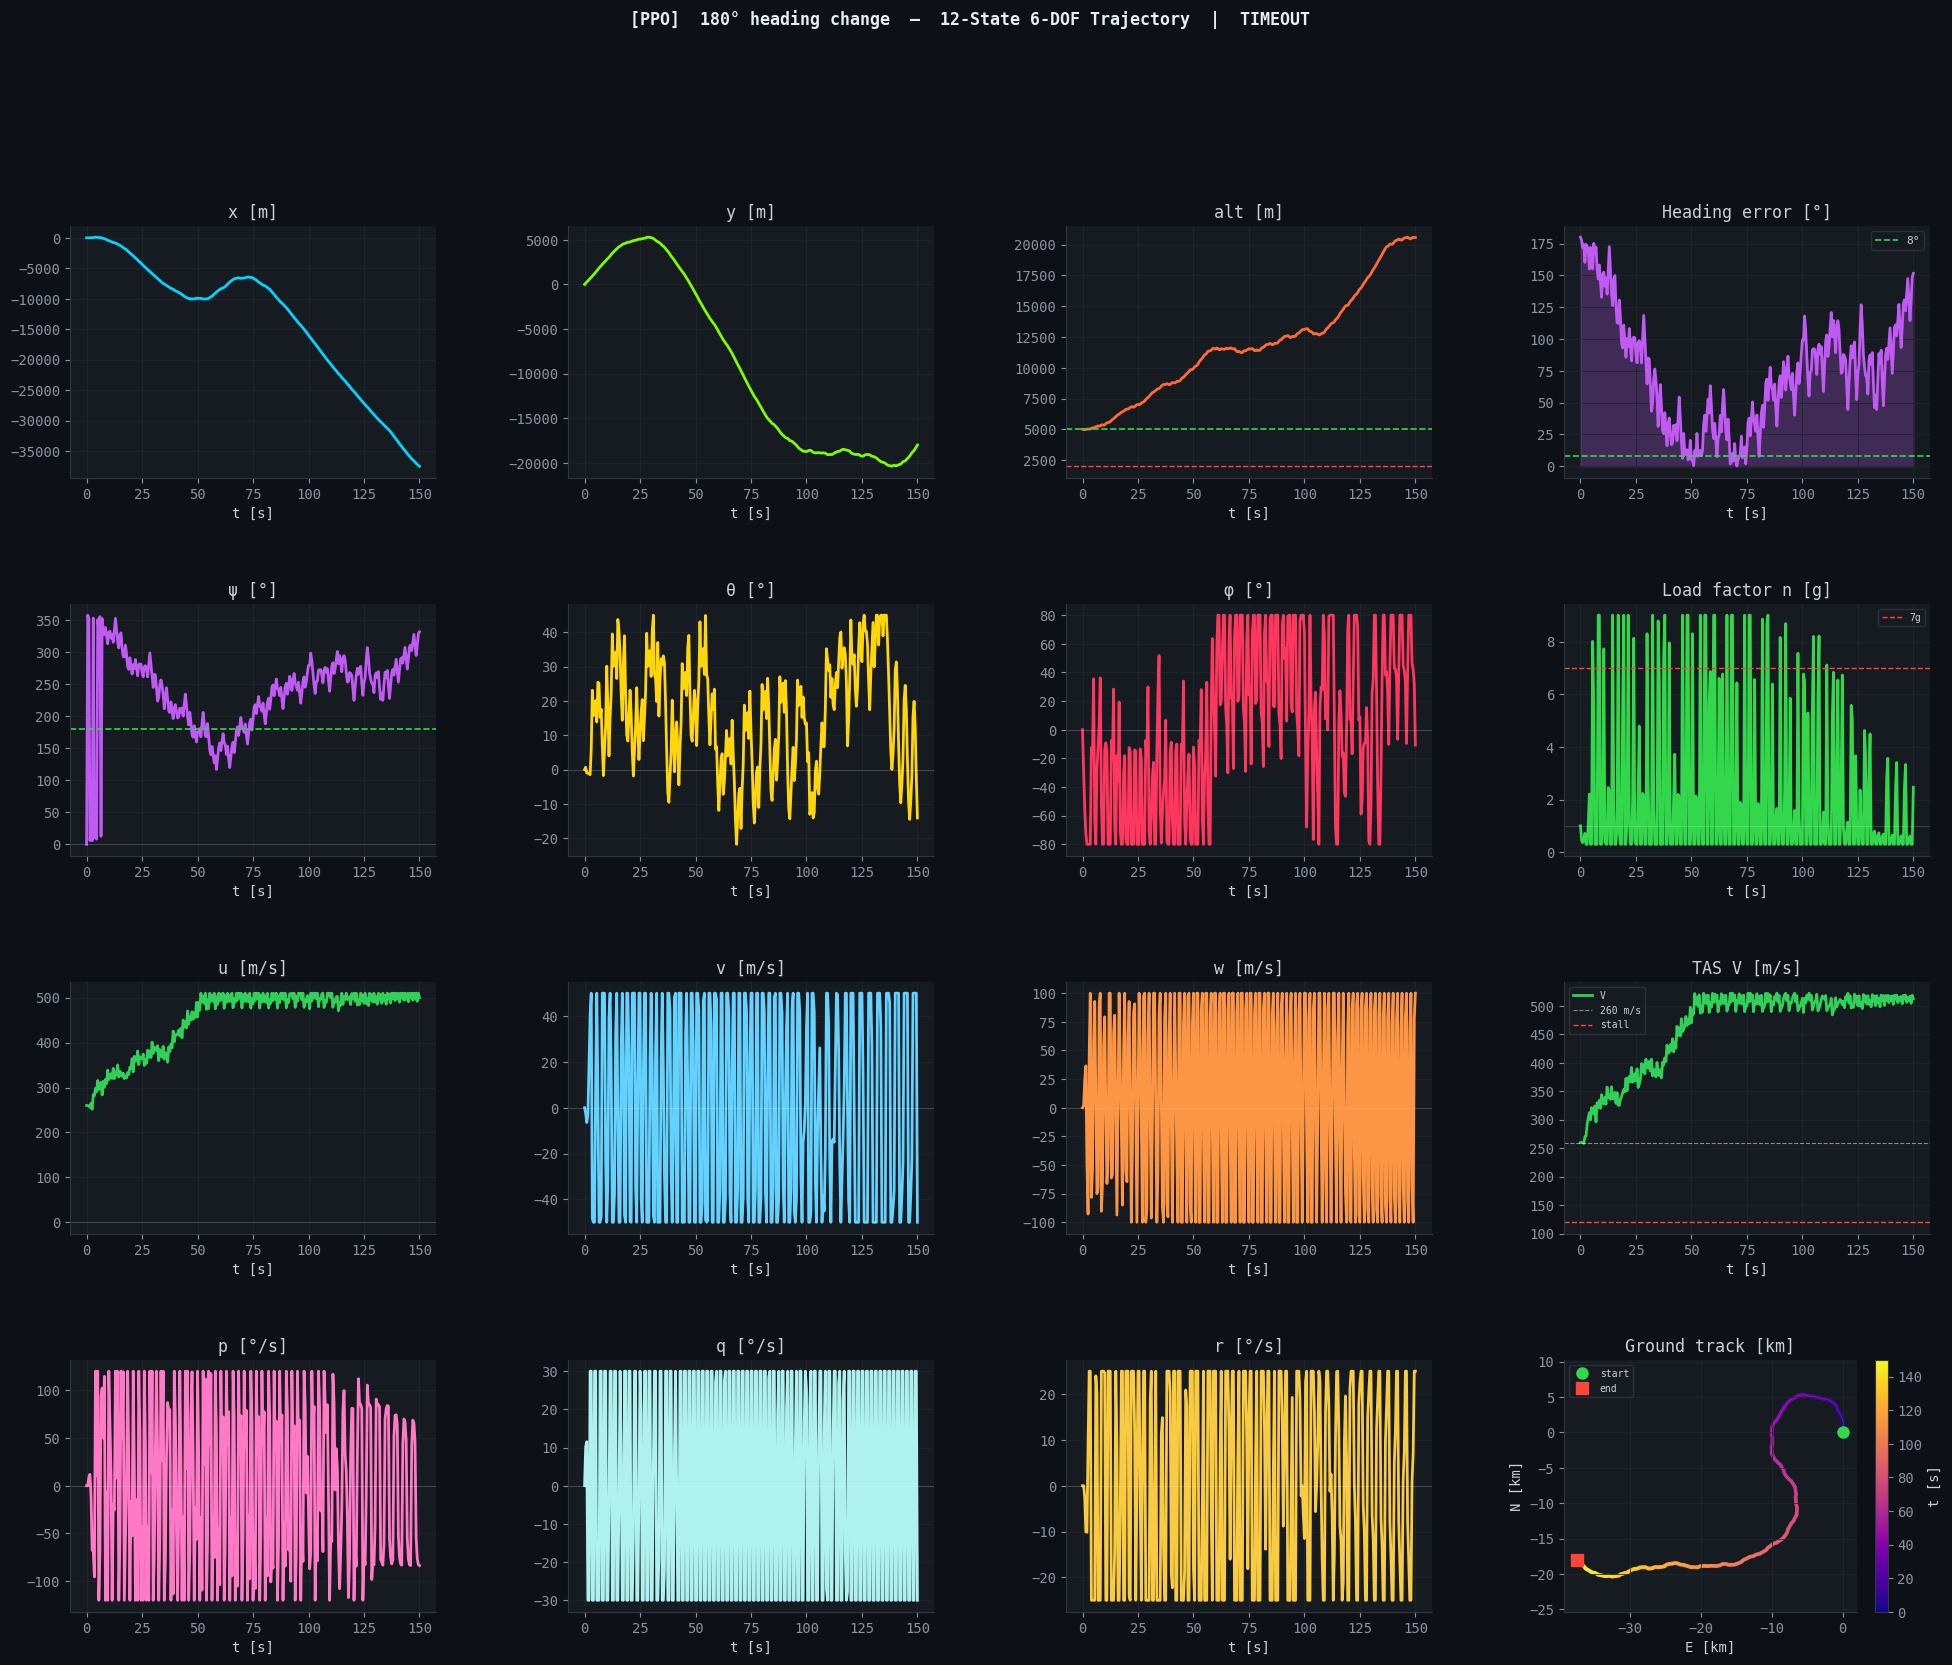

[Saved] PPO_180°_heading_change_12state.png

✓  All done.


In [1]:
"""
=============================================================================
  F-18 HORNET — MULTI-ALGORITHM MULTI-MANEUVER RL
  PPO  |  TRPO  |  DDPG
  12-state 6-DOF model  ·  Position-vector action space  ·  8 maneuvers
=============================================================================

State space  (12-dim, raw physical units — networks learn their own scaling)
─────────────────────────────────────────────────────────────────────────────
  [0]  x        inertial East  position  [m]
  [1]  y        inertial North position  [m]
  [2]  z        inertial Up    position  [m]   (= altitude)
  [3]  psi      yaw / heading  [deg]
  [4]  theta    pitch          [deg]
  [5]  phi      roll / bank    [deg]
  [6]  u        body-axis longitudinal velocity  [m/s]
  [7]  v        body-axis lateral      velocity  [m/s]
  [8]  w        body-axis vertical     velocity  [m/s]
  [9]  p        roll  rate  [deg/s]
  [10] q        pitch rate  [deg/s]
  [11] r        yaw   rate  [deg/s]

Action space  (3-dim, position-vector command)
─────────────────────────────────────────────────────────────────────────────
  a = (Δx_cmd, Δy_cmd, Δz_cmd)  [m per step]
  Guidance law converts this to (ψ_dot_cmd, ḣ_cmd, V_dot_cmd)
  Inner-loop autopilot then drives the actual 6-DOF states.

  This is a guidance-level action space — the agent commands where it wants
  the aircraft to move next; the lower layers handle how.

Algorithms
─────────────────────────────────────────────────────────────────────────────
  PPO   — Proximal Policy Optimisation  (on-policy, clipped surrogate loss)
  TRPO  — Trust Region Policy Optimisation (on-policy, KL constraint, CG)
  DDPG  — Deep Deterministic Policy Gradient (off-policy, replay buffer)

  All three share:
    • Identical 12-dim state input
    • Identical 3-dim position-command output
    • Identical 6-DOF environment
    • Identical per-maneuver reward shaping
    • Common base classes for easy swapping

=============================================================================
"""

import math, random, copy, time, warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.distributions import MultivariateNormal
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[RL-MM]  PyTorch {torch.__version__}  |  device={DEVICE}")
except ImportError:
    raise SystemExit("pip install torch --index-url "
                     "https://download.pytorch.org/whl/cpu")

# ─────────────────────────────────────────────────────────────────────────────
#  DIMENSIONS
# ─────────────────────────────────────────────────────────────────────────────
STATE_DIM  = 12   # raw 6-DOF states
ACTION_DIM = 3    # (Δx, Δy, Δz) position command  [m/step]

# Maximum position command per step (guidance authority)
MAX_DX = 300.0    # m  (East)
MAX_DY = 300.0    # m  (North)
MAX_DZ = 150.0    # m  (Up/Down)


# ═════════════════════════════════════════════════════════════════════════════
# 1.  6-DOF F-18 DYNAMICS  (12 states, body-axis + inertial)
# ═════════════════════════════════════════════════════════════════════════════

class F18_6DOF:
    """
    Full 12-state 6-DOF kinematic model of the F/A-18C Hornet.

    Inertial states  (NED frame)
    ────────────────────────────
      x   East  position  [m]
      y   North position  [m]
      z   Up    position  [m]   (positive up — altitude)

    Euler angles  (aerospace convention)
    ──────────────────────────────────────
      psi    yaw   (heading, 0=North, CW+)  [deg]
      theta  pitch (nose-up+)               [deg]
      phi    roll  (right-wing-down+)       [deg]

    Body-axis velocities
    ─────────────────────
      u   longitudinal (forward)   [m/s]
      v   lateral      (right)     [m/s]
      w   vertical     (down, so we negate for altitude rate)  [m/s]

    Body-axis angular rates
    ────────────────────────
      p   roll  rate  [deg/s]
      q   pitch rate  [deg/s]
      r   yaw   rate  [deg/s]
    """

    # ── F-18C physical constants ──────────────────────────────────────────
    G          = 9.81          # m/s²
    MASS       = 16_651        # kg
    Ixx        = 23_000        # kg·m²  (roll  moment of inertia, approx)
    Iyy        = 169_000       # kg·m²  (pitch)
    Izz        = 185_000       # kg·m²  (yaw)
    Ixz        = 1_500         # kg·m²  (cross)
    WING_AREA  = 37.16         # m²
    SPAN       = 11.43         # m
    CHORD      = 3.51          # m  (mean aerodynamic chord)
    RHO_SL     = 1.225         # kg/m³
    H_SCALE    = 8_500         # m

    # ── Simplified aerodynamic derivatives ───────────────────────────────
    CL0, CL_alpha, CL_q   = 0.10, 5.0, 4.0
    CD0, K_ind             = 0.022, 0.16
    CY_beta, CY_r          = -0.90, 0.30
    Cl_p, Cl_r, Cl_beta    = -0.45, 0.18, -0.08
    Cm_alpha, Cm_q, Cm0    = -1.20, -8.0, 0.02
    Cn_beta, Cn_p, Cn_r    = 0.18, -0.08, -0.25

    # ── Structural limits ─────────────────────────────────────────────────
    PHI_MAX    = 80.0          # deg
    THETA_MAX  = 45.0          # deg
    THETA_MIN  = -30.0         # deg
    V_MIN      = 120.0         # m/s
    V_MAX      = 510.0         # m/s
    NZ_MAX     = 9.0           # g
    P_MAX      = 120.0         # deg/s  (roll rate limit)
    Q_MAX      = 30.0          # deg/s  (pitch rate limit)
    R_MAX      = 25.0          # deg/s  (yaw rate limit)

    # ── Inner-loop autopilot gains ────────────────────────────────────────
    K_PSI   = 3.5              # bank demand per heading-rate error
    K_H     = 1.5              # pitch demand per altitude-rate error
    K_V     = 0.40             # throttle gain on speed error
    BANK_RATE_MAX  = 60.0      # deg/s
    PITCH_RATE_MAX = 15.0      # deg/s

    def __init__(self, dt: float = 0.5):
        self.dt = dt
        self.reset()

    def reset(self, x0=0., y0=0., z0=5000., psi0=0., V0=260.):
        # Inertial position
        self.x, self.y, self.z = x0, y0, z0
        # Euler angles
        self.psi   = psi0
        self.theta = 0.
        self.phi   = 0.
        # Body-axis velocities (start in wings-level cruise)
        self.u = V0        # forward speed
        self.v = 0.        # sideslip velocity
        self.w = 0.        # vertical body velocity
        # Angular rates
        self.p = 0.        # roll rate
        self.q = 0.        # pitch rate
        self.r = 0.        # yaw rate
        # Derived quantities
        self.V     = V0
        self.alpha = 0.    # angle of attack [deg]
        self.beta  = 0.    # sideslip angle  [deg]
        self.nz    = 1.
        self.steps = 0

    # ── Atmosphere ────────────────────────────────────────────────────────
    def _rho(self):
        return self.RHO_SL * math.exp(-max(self.z, 0.) / self.H_SCALE)

    # ── Aerodynamic forces and moments ────────────────────────────────────
    def _aero(self):
        rho  = self._rho()
        self.V = math.sqrt(self.u**2 + self.v**2 + self.w**2)
        V      = max(self.V, 1.)

        self.alpha = math.degrees(math.atan2(self.w, self.u))
        self.beta  = math.degrees(math.asin(np.clip(self.v / V, -1., 1.)))

        alpha_r = math.radians(self.alpha)
        beta_r  = math.radians(self.beta)

        q_bar = 0.5 * rho * V**2
        S     = self.WING_AREA
        b     = self.SPAN
        c_bar = self.CHORD

        # Non-dimensionalise rates
        p_nd = math.radians(self.p) * b / (2*V)
        q_nd = math.radians(self.q) * c_bar / (2*V)
        r_nd = math.radians(self.r) * b / (2*V)

        # Lift, drag, side force coefficients
        CL  = min(self.CL0 + self.CL_alpha*alpha_r + self.CL_q*q_nd, 2.0)
        CD  = self.CD0 + self.K_ind * CL**2
        CY  = self.CY_beta*beta_r + self.CY_r*r_nd

        # Moment coefficients
        Cl  = self.Cl_p*p_nd + self.Cl_r*r_nd + self.Cl_beta*beta_r
        Cm  = self.Cm0 + self.Cm_alpha*alpha_r + self.Cm_q*q_nd
        Cn  = self.Cn_beta*beta_r + self.Cn_p*p_nd + self.Cn_r*r_nd

        # Wind-to-body transformation (simplified, use alpha, beta)
        ca, sa = math.cos(alpha_r), math.sin(alpha_r)
        cb, sb = math.cos(beta_r),  math.sin(beta_r)

        # Aerodynamic forces in body axes
        L = q_bar * S * CL
        D = q_bar * S * CD
        Y = q_bar * S * CY

        # Body-axis force components from L, D, Y
        Xa = -D*ca*cb + L*sa          # axial (forward)
        Ya =  Y                        # lateral
        Za = -D*sa*cb - L*ca           # normal (down in body)

        # Aerodynamic moments
        La_m = q_bar * S * b     * Cl  # rolling moment
        Ma   = q_bar * S * c_bar * Cm  # pitching moment
        Na   = q_bar * S * b     * Cn  # yawing moment

        return Xa, Ya, Za, La_m, Ma, Na, L

    # ── Guidance law: position command → rate commands ────────────────────
    def _guidance(self, dx_cmd: float, dy_cmd: float, dz_cmd: float
                  ) -> Tuple[float, float, float]:
        """
        Convert a desired 3D displacement (NED) to rate commands.

        dx_cmd  [m]  desired East  displacement this step
        dy_cmd  [m]  desired North displacement this step
        dz_cmd  [m]  desired Up    displacement this step

        Returns: (psi_dot_cmd [deg/s], hdot_cmd [m/s], Vdot_cmd [m/s²])
        """
        # Desired heading from displacement vector
        psi_desired = math.degrees(math.atan2(dx_cmd, dy_cmd)) % 360.
        herr = psi_desired - self.psi
        while herr >  180.: herr -= 360.
        while herr <= -180.: herr += 360.
        psi_dot_cmd = np.clip(3.0 * herr, -30., 30.)    # P-controller

        # Desired altitude rate from vertical displacement
        hdot_cmd = np.clip(dz_cmd / self.dt, -40., 40.)

        # Desired speed from horizontal magnitude vs current speed
        horiz_mag  = math.sqrt(dx_cmd**2 + dy_cmd**2)
        V_desired  = np.clip(horiz_mag / self.dt, self.V_MIN, self.V_MAX)
        Vdot_cmd   = np.clip(0.4*(V_desired - self.V), -20., 20.)

        return psi_dot_cmd, hdot_cmd, Vdot_cmd

    # ── Full integration step ─────────────────────────────────────────────
    def step(self, dx_cmd: float, dy_cmd: float, dz_cmd: float) -> dict:
        """
        Integrate one dt given position commands.
        Returns the new 12-state dict.
        """
        self.steps += 1

        # 1. Guidance: position → rate commands
        psi_dot_cmd, hdot_cmd, Vdot_cmd = self._guidance(dx_cmd, dy_cmd, dz_cmd)

        # 2. Inner-loop autopilot: rate commands → attitude demands
        # Bank demand from heading-rate command
        phi_demand   = np.clip(self.K_PSI*(psi_dot_cmd - self.r*math.cos(math.radians(self.phi))),
                               -self.PHI_MAX, self.PHI_MAX)
        theta_demand = np.clip(self.K_H*(hdot_cmd - (-self.w)),
                               self.THETA_MIN, self.THETA_MAX)

        # 3. Rate-limited actuator response
        dphi   = np.clip(phi_demand   - self.phi,
                         -self.BANK_RATE_MAX*self.dt,   self.BANK_RATE_MAX*self.dt)
        dtheta = np.clip(theta_demand - self.theta,
                         -self.PITCH_RATE_MAX*self.dt,  self.PITCH_RATE_MAX*self.dt)

        self.phi   = np.clip(self.phi   + dphi,   -self.PHI_MAX,   self.PHI_MAX)
        self.theta = np.clip(self.theta + dtheta,  self.THETA_MIN,  self.THETA_MAX)

        # 4. Aerodynamic forces and moments
        Xa, Ya, Za, La_m, Ma, Na, Lift = self._aero()

        # 5. Gravity in body axes
        phi_r   = math.radians(self.phi)
        theta_r = math.radians(self.theta)
        Gx  = -self.G * math.sin(theta_r)
        Gy  =  self.G * math.cos(theta_r) * math.sin(phi_r)
        Gz  =  self.G * math.cos(theta_r) * math.cos(phi_r)

        # 6. Thrust (proportional speed controller)
        Thrust = np.clip(self.MASS*(Vdot_cmd + self.G*math.sin(theta_r)),
                         0., self.MASS*40.)

        # 7. Total body-axis force
        Fx = Xa + Thrust + self.MASS*Gx
        Fy = Ya          + self.MASS*Gy
        Fz = Za          + self.MASS*Gz

        # 8. Linear accelerations → velocity update
        ax = Fx/self.MASS - (self.q*self.w - self.r*self.v) * math.pi/180
        ay = Fy/self.MASS - (self.r*self.u - self.p*self.w) * math.pi/180
        az = Fz/self.MASS - (self.p*self.v - self.q*self.u) * math.pi/180

        self.u = np.clip(self.u + ax*self.dt, -self.V_MAX, self.V_MAX)
        self.v = np.clip(self.v + ay*self.dt, -50., 50.)
        self.w = np.clip(self.w + az*self.dt, -100., 100.)

        # 9. Angular rates (simplified Euler equations)
        Ixx, Iyy, Izz, Ixz = self.Ixx, self.Iyy, self.Izz, self.Ixz
        Gam = Ixx*Izz - Ixz**2
        p_dot = (Izz*La_m + Ixz*Na - (Izz*(Izz-Iyy)*math.radians(self.r)
                  + Ixz*(Ixx-Iyy+Izz)*math.radians(self.p))*math.radians(self.q)) / Gam
        q_dot = (Ma - (Ixx-Izz)*math.radians(self.p)*math.radians(self.r)
                  - Ixz*(math.radians(self.p)**2 - math.radians(self.r)**2)) / Iyy
        r_dot = (Ixx*Na + Ixz*La_m + (Ixx*(Ixx-Iyy)*math.radians(self.p)
                  + Ixz*(Ixx-Iyy+Izz)*math.radians(self.r))*math.radians(self.q)) / Gam

        self.p = np.clip(self.p + math.degrees(p_dot)*self.dt, -self.P_MAX, self.P_MAX)
        self.q = np.clip(self.q + math.degrees(q_dot)*self.dt, -self.Q_MAX, self.Q_MAX)
        self.r = np.clip(self.r + math.degrees(r_dot)*self.dt, -self.R_MAX, self.R_MAX)

        # 10. Euler angle kinematics
        psi_dot   = (math.radians(self.q)*math.sin(phi_r)
                     + math.radians(self.r)*math.cos(phi_r)) / math.cos(theta_r)
        theta_dot = (math.radians(self.q)*math.cos(phi_r)
                     - math.radians(self.r)*math.sin(phi_r))
        phi_dot   = (math.radians(self.p)
                     + (math.radians(self.q)*math.sin(phi_r)
                        + math.radians(self.r)*math.cos(phi_r)) * math.tan(theta_r))

        self.psi   = (self.psi   + math.degrees(psi_dot)*self.dt)   % 360.
        self.theta = np.clip(self.theta + math.degrees(theta_dot)*self.dt,
                             self.THETA_MIN, self.THETA_MAX)
        self.phi   = np.clip(self.phi   + math.degrees(phi_dot)*self.dt,
                             -self.PHI_MAX, self.PHI_MAX)

        # 11. Inertial position (NED body→inertial rotation)
        cpsi, spsi = math.cos(math.radians(self.psi)), math.sin(math.radians(self.psi))
        ctheta     = math.cos(theta_r)
        stheta     = math.sin(theta_r)
        cphi, sphi = math.cos(phi_r), math.sin(phi_r)

        # Rotation matrix rows (body → NED)
        R11 = ctheta*cpsi
        R12 = sphi*stheta*cpsi - cphi*spsi
        R13 = cphi*stheta*cpsi + sphi*spsi
        R21 = ctheta*spsi
        R22 = sphi*stheta*spsi + cphi*cpsi
        R23 = cphi*stheta*spsi - sphi*cpsi
        R31 = -stheta
        R32 = sphi*ctheta
        R33 = cphi*ctheta

        # NED velocities (inertial)
        V_north = R11*self.u + R12*self.v + R13*self.w   # actually: body→NED row 2
        V_east  = R21*self.u + R22*self.v + R23*self.w
        V_down  = R31*self.u + R32*self.v + R33*self.w

        # Update position  (x=East, y=North, z=Up)
        self.x += V_east  * self.dt
        self.y += V_north * self.dt
        self.z -= V_down  * self.dt     # NED down → positive up

        # 12. Load factor
        self.nz = np.clip(Lift*math.cos(phi_r)/(self.MASS*self.G), 0.3, self.NZ_MAX)
        self.V  = math.sqrt(self.u**2 + self.v**2 + self.w**2)

        return self.state_dict()

    def state_dict(self) -> dict:
        return dict(x=self.x, y=self.y, z=self.z,
                    psi=self.psi, theta=self.theta, phi=self.phi,
                    u=self.u, v=self.v, w=self.w,
                    p=self.p, q=self.q, r=self.r,
                    V=self.V, alpha=self.alpha, beta=self.beta, nz=self.nz)

    def state_vector(self) -> np.ndarray:
        """12-dim raw state vector (no normalisation)."""
        return np.array([
            self.x, self.y, self.z,
            self.psi, self.theta, self.phi,
            self.u, self.v, self.w,
            self.p, self.q, self.r,
        ], dtype=np.float32)


# ═════════════════════════════════════════════════════════════════════════════
# 2.  MANEUVER SPECIFICATIONS
# ═════════════════════════════════════════════════════════════════════════════

@dataclass
class ManeuverSpec:
    name        : str
    category    : str          # nav / offensive / defensive

    # Initial conditions
    x0          : float = 0.
    y0          : float = 0.
    z0          : float = 5000.
    psi0        : float = 0.
    V0          : float = 260.

    # Goals
    target_psi  : float = 180.
    target_z    : float = 5000.
    target_V    : float = 260.

    # Termination
    max_steps   : int   = 300
    z_min       : float = 2000.
    V_crash     : float = 120.
    success_herr: float = 8.
    success_hold: int   = 6

    # Reward weights
    w_pos       : float = 1.0    # position-error reward (main signal)
    w_heading   : float = 80.    # Gaussian heading reward
    sigma_herr  : float = 40.    # deg — Gaussian width
    w_progress  : float = 2.5    # heading progress
    w_altitude  : float = 0.03   # altitude maintenance
    w_vel       : float = 0.01   # speed maintenance
    w_sideslip  : float = 1.5    # sideslip penalty
    w_nz        : float = 4.0    # g-load penalty above nz_thresh
    nz_thresh   : float = 7.0
    w_roll_rate : float = 0.0    # roll-rate bonus (barrel roll etc.)
    w_alt_gain  : float = 0.0    # altitude-change bonus
    r_success   : float = 600.
    r_crash     : float = -400.
    r_stall     : float = -300.

    # Phase-specific
    extra       : dict = field(default_factory=dict)


def build_all_specs() -> Dict[str, ManeuverSpec]:
    s = {}

    s['M1'] = ManeuverSpec(
        name='90° heading change', category='nav',
        target_psi=90., target_z=5000.,
        sigma_herr=30., w_heading=100., w_progress=3.,
        r_success=500., max_steps=200,
    )
    s['M2'] = ManeuverSpec(
        name='180° heading change', category='nav',
        target_psi=180., target_z=5000.,
        sigma_herr=40., w_heading=100., w_progress=3.,
        r_success=600., max_steps=300,
    )
    s['M3'] = ManeuverSpec(
        name='Immelmann turn', category='offensive',
        z0=5000., target_psi=180., target_z=6500.,
        sigma_herr=50., w_heading=70., w_progress=2.,
        w_altitude=0.05, w_alt_gain=0.8, w_roll_rate=1.0,
        r_success=700., max_steps=320,
        extra=dict(min_alt_gain=800.),
    )
    s['M4'] = ManeuverSpec(
        name='Split-S', category='defensive',
        z0=7500., target_psi=180., target_z=5200.,
        sigma_herr=50., w_heading=70., w_progress=2.,
        w_altitude=0.03, w_roll_rate=1.5,
        r_success=700., z_min=3200., max_steps=320,
        extra=dict(target_V_gain=25.),
    )
    s['M5'] = ManeuverSpec(
        name='Barrel roll', category='offensive',
        target_psi=0., target_z=5000.,
        sigma_herr=60., w_heading=55., w_progress=1.2,
        w_altitude=0.04, w_roll_rate=3.5,
        r_success=700., max_steps=400,
        extra=dict(require_full_360=True),
    )
    s['M6'] = ManeuverSpec(
        name='High yo-yo', category='offensive',
        target_psi=90., target_z=5000.,
        sigma_herr=35., w_heading=85., w_progress=2.5,
        w_altitude=0.04, w_alt_gain=0.3, w_roll_rate=1.0,
        r_success=650., max_steps=350,
        extra=dict(phase_climb=700.),
    )
    s['M7'] = ManeuverSpec(
        name='Low yo-yo', category='offensive',
        target_psi=90., target_z=5000.,
        sigma_herr=35., w_heading=85., w_progress=2.5,
        w_altitude=0.03, w_vel=-0.005,
        w_roll_rate=1.0, r_success=650., max_steps=350,
        extra=dict(phase_dive=500.),
    )
    s['M8'] = ManeuverSpec(
        name="Pugachev's cobra", category='defensive',
        target_psi=0., target_z=5000.,
        sigma_herr=90., w_heading=15., w_progress=0.,
        w_altitude=0.05, w_alt_gain=-0.2,
        r_success=800., max_steps=200,
        extra=dict(cobra_mode=True,
                   target_min_V=140.,
                   target_max_pitch=75.),
    )
    return s


SPECS = build_all_specs()


# ═════════════════════════════════════════════════════════════════════════════
# 3.  REWARD FUNCTION  (per-maneuver, position-aware)
# ═════════════════════════════════════════════════════════════════════════════

def _herr(psi: float, target: float) -> float:
    e = target - psi
    while e >  180.: e -= 360.
    while e <= -180.: e += 360.
    return e

def compute_reward(sv_prev: dict, sv: dict, spec: ManeuverSpec,
                   action: np.ndarray, done: bool, cause: str) -> float:

    herr_now  = abs(_herr(sv['psi'],      spec.target_psi))
    herr_prev = abs(_herr(sv_prev['psi'], spec.target_psi))

    # ── 1. Position-vector progress reward ───────────────────────────────
    # How much did we move toward the goal position?
    # Goal position is defined by target heading direction from start
    tgt_rad = math.radians(spec.target_psi)
    # Ideal trajectory point: somewhere along target heading
    # Use heading error reduction as proxy for position progress
    r_pos = spec.w_pos * (herr_prev - herr_now) * 5.0

    # ── 2. Gaussian heading potential ────────────────────────────────────
    r_heading = spec.w_heading * math.exp(-0.5*(herr_now/spec.sigma_herr)**2)

    # ── 3. Altitude maintenance ───────────────────────────────────────────
    r_alt = -spec.w_altitude * abs(sv['z'] - spec.target_z)

    # ── 4. Altitude rate bonus (Immelmann wants climb, Cobra wants level) ─
    vert_vel = sv['z'] - sv_prev['z']  # actual altitude change this step
    r_alt_gain = spec.w_alt_gain * vert_vel

    # ── 5. Velocity ───────────────────────────────────────────────────────
    r_vel = -spec.w_vel * abs(sv['V'] - spec.target_V) if spec.w_vel > 0 else \
            spec.w_vel * (sv['V'] - spec.target_V)     # negative = reward gain

    # ── 6. Sideslip ───────────────────────────────────────────────────────
    r_slip = -spec.w_sideslip * abs(sv['beta'])

    # ── 7. Load factor ────────────────────────────────────────────────────
    r_nz = -spec.w_nz * max(0., sv['nz'] - spec.nz_thresh)

    # ── 8. Roll-rate bonus (barrel roll, Immelmann, Split-S) ─────────────
    r_roll = spec.w_roll_rate * abs(sv['p'])

    # ── 9. Cobra special: reward high pitch + speed bleed ─────────────────
    r_cobra = 0.
    if spec.extra.get('cobra_mode'):
        v_bleed  = max(0., spec.target_V - sv['V'])
        r_cobra  = 0.4*v_bleed + 2.0*max(0., abs(sv['theta']) - 40.)

    # ── 10. Smoothness: penalise large action magnitudes (physical realism)
    r_smooth = -0.001 * float(np.sum(action**2))

    # ── 11. Terminal ──────────────────────────────────────────────────────
    r_term = 0.
    if cause == 'success':
        wl  = 1. - abs(sv['phi'])/80.
        al  = 1. - min(abs(sv['z']-spec.target_z), 500.)/500.
        r_term = spec.r_success + 120.*wl + 80.*al
    elif cause == 'crash':
        r_term = spec.r_crash
    elif cause == 'stall':
        r_term = spec.r_stall
    elif cause == 'timeout':
        r_term = -60. + 40.*(1. - herr_now/180.)

    return float(r_pos + r_heading + r_alt + r_alt_gain + r_vel
                 + r_slip + r_nz + r_roll + r_cobra + r_smooth + r_term)


# ═════════════════════════════════════════════════════════════════════════════
# 4.  ENVIRONMENT
# ═════════════════════════════════════════════════════════════════════════════

class ManeuverEnv:
    """
    Wraps F18_6DOF for one maneuver.
    State  : 12-dim raw  [x,y,z,psi,theta,phi,u,v,w,p,q,r]
    Action : 3-dim (Δx,Δy,Δz) in [-1,1], rescaled to physical units
    """
    def __init__(self, spec: ManeuverSpec, dt: float = 0.5):
        self.spec = spec
        self.dyn  = F18_6DOF(dt=dt)
        self._sv  = None
        self._sv_prev = None
        self._success_ctr = 0
        self._hdg_change  = 0.   # cumulative for barrel roll
        self._prev_psi    = 0.

    def reset(self) -> np.ndarray:
        self.dyn.reset(self.spec.x0, self.spec.y0, self.spec.z0,
                       self.spec.psi0, self.spec.V0)
        self._sv = self.dyn.state_dict()
        self._sv_prev = self._sv.copy()
        self._success_ctr = 0
        self._hdg_change  = 0.
        self._prev_psi    = self._sv['psi']
        return self.dyn.state_vector()

    def step(self, action: np.ndarray) -> Tuple[np.ndarray, float, bool, dict]:
        """
        action: np.ndarray shape (3,) in [-1, 1]
        Rescaled to (Δx, Δy, Δz) in metres.
        """
        a = np.clip(action, -1., 1.)
        dx = a[0] * MAX_DX
        dy = a[1] * MAX_DY
        dz = a[2] * MAX_DZ

        self._sv_prev = self._sv.copy()
        self._sv = self.dyn.step(dx, dy, dz)

        # Cumulative heading change (barrel roll)
        dpsi = abs((_herr(self._sv['psi'], self._prev_psi)))
        self._hdg_change += dpsi
        self._prev_psi    = self._sv['psi']

        herr  = abs(_herr(self._sv['psi'], self.spec.target_psi))
        done  = False
        cause = 'running'

        # Termination
        if self._sv['z'] < self.spec.z_min:
            done, cause = True, 'crash'
        elif self._sv['V'] < self.spec.V_crash:
            done, cause = True, 'stall'
        elif self.dyn.steps >= self.spec.max_steps:
            done, cause = True, 'timeout'
        else:
            ok = herr <= self.spec.success_herr

            if self.spec.extra.get('require_full_360'):
                ok = ok and self._hdg_change >= 340.
            if self.spec.extra.get('min_alt_gain'):
                ok = ok and (self._sv['z']-self.spec.z0) >= self.spec.extra['min_alt_gain']
            if self.spec.extra.get('cobra_mode'):
                ok = (self._sv['V'] <= self.spec.extra['target_min_V']
                      and abs(self._sv['theta']) < 20.
                      and self._sv['z'] > self.spec.z_min + 500.)

            if ok:
                self._success_ctr += 1
                if self._success_ctr >= self.spec.success_hold:
                    done, cause = True, 'success'
            else:
                self._success_ctr = 0

        reward = compute_reward(self._sv_prev, self._sv, self.spec,
                                a, done, cause)
        obs    = self.dyn.state_vector()
        info   = dict(cause=cause, herr=herr, z=self._sv['z'],
                      V=self._sv['V'], phi=self._sv['phi'],
                      theta=self._sv['theta'], nz=self._sv['nz'],
                      hdg_change=self._hdg_change)
        return obs, reward, done, info

    @property
    def state(self) -> dict:
        return self._sv.copy() if self._sv else {}


# ═════════════════════════════════════════════════════════════════════════════
# 5.  NEURAL NETWORK BUILDING BLOCKS
# ═════════════════════════════════════════════════════════════════════════════

def _mlp(in_d: int, out_d: int, hidden=(256,256), activation=nn.Tanh):
    """MLP with configurable hidden layers and activation."""
    layers, prev = [], in_d
    for h in hidden:
        layers += [nn.Linear(prev, h), activation()]
        prev = h
    layers.append(nn.Linear(prev, out_d))
    return nn.Sequential(*layers)


class PolicyNet(nn.Module):
    """
    Shared actor architecture for PPO and TRPO.
    Outputs mean of a Gaussian policy; log_std is a learnable parameter.
    """
    def __init__(self, s_dim, a_dim, hidden=(256,256), log_std_init=-0.5):
        super().__init__()
        self.net     = _mlp(s_dim, a_dim, hidden)
        self.log_std = nn.Parameter(torch.ones(a_dim)*log_std_init)
        # Small output init for stable early actions
        nn.init.uniform_(self.net[-1].weight, -3e-3, 3e-3)
        nn.init.uniform_(self.net[-1].bias,   -3e-3, 3e-3)

    def forward(self, s):
        mean = torch.tanh(self.net(s))       # actions ∈ (-1,1)
        std  = torch.exp(self.log_std).expand_as(mean)
        return mean, std

    def get_dist(self, s):
        mean, std = self.forward(s)
        cov  = torch.diag_embed(std**2)
        return MultivariateNormal(mean, cov)

    @torch.no_grad()
    def act(self, obs: np.ndarray, deterministic=False) -> np.ndarray:
        s = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        mean, std = self.forward(s)
        if deterministic:
            a = mean
        else:
            a = mean + std*torch.randn_like(std)
        return a.squeeze(0).cpu().numpy().clip(-1.,1.).astype(np.float32)


class ValueNet(nn.Module):
    def __init__(self, s_dim, hidden=(256,256)):
        super().__init__()
        self.net = _mlp(s_dim, 1, hidden)
    def forward(self, s): return self.net(s)


class DDPGActor(nn.Module):
    def __init__(self, s_dim, a_dim, hidden=(256,256)):
        super().__init__()
        self.net = _mlp(s_dim, a_dim, hidden)
        nn.init.uniform_(self.net[-1].weight, -3e-3, 3e-3)
        nn.init.uniform_(self.net[-1].bias,   -3e-3, 3e-3)
    def forward(self, s): return torch.tanh(self.net(s))

    @torch.no_grad()
    def act(self, obs, noise=0.):
        s = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        a = self.forward(s).squeeze(0).cpu().numpy()
        if noise > 0.: a += np.random.normal(0., noise, a.shape)
        return a.clip(-1.,1.).astype(np.float32)


class DDPGCritic(nn.Module):
    def __init__(self, s_dim, a_dim, hidden=(256,256)):
        super().__init__()
        self.net = _mlp(s_dim+a_dim, 1, hidden)
    def forward(self, s, a): return self.net(torch.cat([s,a],-1))


# ═════════════════════════════════════════════════════════════════════════════
# 6.  REPLAY BUFFER  (DDPG only)
# ═════════════════════════════════════════════════════════════════════════════

class ReplayBuffer:
    def __init__(self, s_dim, a_dim, cap=200_000):
        self.cap=cap; self.ptr=0; self.size=0
        self.S  = np.zeros((cap,s_dim),  np.float32)
        self.A  = np.zeros((cap,a_dim),  np.float32)
        self.R  = np.zeros((cap,1),      np.float32)
        self.S2 = np.zeros((cap,s_dim),  np.float32)
        self.D  = np.zeros((cap,1),      np.float32)

    def add(self, s, a, r, s2, done):
        i=self.ptr%self.cap
        self.S[i]=s; self.A[i]=a; self.R[i]=r; self.S2[i]=s2; self.D[i]=done
        self.ptr=(self.ptr+1)%self.cap; self.size=min(self.size+1,self.cap)

    def sample(self, n):
        idx = np.random.randint(0,self.size,n)
        t = lambda x: torch.FloatTensor(x[idx]).to(DEVICE)
        return t(self.S), t(self.A), t(self.R), t(self.S2), t(self.D)


# ═════════════════════════════════════════════════════════════════════════════
# 7.  PPO AGENT
# ═════════════════════════════════════════════════════════════════════════════

class PPOAgent:
    """
    Proximal Policy Optimisation.

    On-policy, collects N steps per update, optimises with clipped surrogate
    loss for K epochs. Works well out-of-the-box for continuous control.

    Key hyperparameters
    ────────────────────
    clip_eps  : 0.2    surrogate clipping range
    gamma     : 0.99   discount
    lam       : 0.95   GAE lambda
    K_epochs  : 8      gradient steps per rollout
    rollout   : 2048   steps between updates
    """
    def __init__(self, s_dim=STATE_DIM, a_dim=ACTION_DIM,
                 actor_lr=3e-4, critic_lr=1e-3,
                 clip_eps=0.20, gamma=0.99, lam=0.95,
                 K_epochs=8, rollout=2048,
                 hidden=(256,256), entropy_coef=0.005,
                 max_grad_norm=0.5):
        self.clip=clip_eps; self.gamma=gamma; self.lam=lam
        self.K=K_epochs; self.rollout=rollout
        self.ent_coef=entropy_coef; self.mgn=max_grad_norm

        self.policy  = PolicyNet(s_dim, a_dim, hidden).to(DEVICE)
        self.policy_old = copy.deepcopy(self.policy)
        self.value   = ValueNet(s_dim, hidden).to(DEVICE)

        self.opt_p   = optim.Adam(self.policy.parameters(), lr=actor_lr, eps=1e-5)
        self.opt_v   = optim.Adam(self.value.parameters(),  lr=critic_lr, eps=1e-5)

        self.p_losses: List[float] = []
        self.v_losses: List[float] = []

    def act(self, obs, deterministic=False):
        return self.policy.act(obs, deterministic)

    def _gae(self, rewards, values, dones):
        """Generalised Advantage Estimation."""
        T   = len(rewards)
        adv = np.zeros(T, np.float32)
        ret = np.zeros(T, np.float32)
        gae = 0.
        for t in reversed(range(T)):
            nxt = values[t+1] if t < T-1 else 0.
            delta = rewards[t] + self.gamma*(1-dones[t])*nxt - values[t]
            gae   = delta + self.gamma*self.lam*(1-dones[t])*gae
            adv[t] = gae
            ret[t] = adv[t] + values[t]
        return adv, ret

    def update(self, batch: dict):
        """Update from a collected rollout batch."""
        S  = torch.FloatTensor(batch['obs']).to(DEVICE)
        A  = torch.FloatTensor(batch['acts']).to(DEVICE)
        Rt = torch.FloatTensor(batch['rets']).to(DEVICE)
        Adv= torch.FloatTensor(batch['advs']).to(DEVICE)
        Adv= (Adv - Adv.mean()) / (Adv.std() + 1e-8)

        # Old log probs (fixed)
        with torch.no_grad():
            dist_old = self.policy_old.get_dist(S)
            lp_old   = dist_old.log_prob(A).unsqueeze(-1)

        for _ in range(self.K):
            dist = self.policy.get_dist(S)
            lp   = dist.log_prob(A).unsqueeze(-1)
            ratio= torch.exp(lp - lp_old)

            # Clipped surrogate
            obj1 = ratio * Adv
            obj2 = ratio.clamp(1-self.clip, 1+self.clip) * Adv
            loss_p = -torch.min(obj1, obj2).mean()
            loss_e = -dist.entropy().mean()

            # Policy gradient step
            self.opt_p.zero_grad()
            (loss_p + self.ent_coef*loss_e).backward()
            nn.utils.clip_grad_norm_(self.policy.parameters(), self.mgn)
            self.opt_p.step()

            # Value function step
            V_pred   = self.value(S)
            loss_v   = F.mse_loss(V_pred, Rt.unsqueeze(-1))
            self.opt_v.zero_grad(); loss_v.backward()
            nn.utils.clip_grad_norm_(self.value.parameters(), self.mgn)
            self.opt_v.step()

            self.p_losses.append(float(loss_p))
            self.v_losses.append(float(loss_v))

        # Sync old policy
        self.policy_old.load_state_dict(self.policy.state_dict())

    def save(self, path):
        torch.save({'policy': self.policy.state_dict(),
                    'value':  self.value.state_dict()}, path)

    def load(self, path):
        ck = torch.load(path, map_location=DEVICE)
        self.policy.load_state_dict(ck['policy'])
        self.policy_old = copy.deepcopy(self.policy)
        self.value.load_state_dict(ck['value'])


# ═════════════════════════════════════════════════════════════════════════════
# 8.  TRPO AGENT
# ═════════════════════════════════════════════════════════════════════════════

class TRPOAgent:
    """
    Trust Region Policy Optimisation.

    Uses conjugate gradient to compute the natural policy gradient and a
    backtracking line search to enforce the KL constraint.

    Key hyperparameters
    ────────────────────
    max_kl    : 0.01   max KL divergence per update (trust region size)
    cg_iters  : 10     conjugate gradient iterations
    damping   : 0.1    Hessian damping for numerical stability
    rollout   : 2048   steps per update
    """
    def __init__(self, s_dim=STATE_DIM, a_dim=ACTION_DIM,
                 critic_lr=1e-3, max_kl=0.01,
                 cg_iters=10, damping=0.1,
                 gamma=0.99, lam=0.95,
                 rollout=2048, hidden=(256,256)):
        self.max_kl=max_kl; self.cg_iters=cg_iters
        self.damp=damping; self.gamma=gamma; self.lam=lam
        self.rollout=rollout

        self.policy = PolicyNet(s_dim, a_dim, hidden).to(DEVICE)
        self.value  = ValueNet(s_dim,  hidden).to(DEVICE)
        self.opt_v  = optim.Adam(self.value.parameters(), lr=critic_lr, eps=1e-5)

        self.p_losses: List[float] = []
        self.v_losses: List[float] = []

    def act(self, obs, deterministic=False):
        return self.policy.act(obs, deterministic)

    def _gae(self, rewards, values, dones):
        T=len(rewards); adv=np.zeros(T,np.float32); gae=0.
        for t in reversed(range(T)):
            nxt  = values[t+1] if t < T-1 else 0.
            delta= rewards[t] + self.gamma*(1-dones[t])*nxt - values[t]
            gae  = delta + self.gamma*self.lam*(1-dones[t])*gae
            adv[t]=gae
        ret = adv + np.array(values[:T])
        return adv, ret

    # ── CG and Hessian-vector product ─────────────────────────────────────
    def _flat_grad(self, loss, params, retain=False):
        grads = torch.autograd.grad(loss, params, retain_graph=retain,
                                    create_graph=False)
        return torch.cat([g.contiguous().view(-1) for g in grads])

    def _hvp(self, kl, params, v):
        """Fisher-vector product via double backprop."""
        grads = torch.autograd.grad(kl, params, create_graph=True)
        flat_g = torch.cat([g.contiguous().view(-1) for g in grads])
        gvp = (flat_g * v).sum()
        hvp = torch.autograd.grad(gvp, params, retain_graph=False)
        return torch.cat([h.contiguous().view(-1) for h in hvp]).detach() + self.damp*v

    def _cg(self, Avp_fn, b):
        """Conjugate gradient solver: Ax=b where A is the Fisher matrix."""
        x = torch.zeros_like(b)
        r = b.clone(); p = b.clone(); rs_old = r.dot(r)
        for _ in range(self.cg_iters):
            Ap = Avp_fn(p)
            alpha = rs_old / (p.dot(Ap) + 1e-8)
            x += alpha*p; r -= alpha*Ap
            rs_new = r.dot(r)
            if rs_new < 1e-10: break
            p = r + (rs_new/rs_old)*p
            rs_old = rs_new
        return x

    def _set_flat_params(self, params, flat_params):
        idx = 0
        for p in params:
            n = p.numel()
            p.data.copy_(flat_params[idx:idx+n].view(p.shape))
            idx += n

    def update(self, batch: dict):
        S   = torch.FloatTensor(batch['obs']).to(DEVICE)
        A   = torch.FloatTensor(batch['acts']).to(DEVICE)
        Adv = torch.FloatTensor(batch['advs']).to(DEVICE)
        Rt  = torch.FloatTensor(batch['rets']).to(DEVICE)
        Adv = (Adv - Adv.mean()) / (Adv.std() + 1e-8)

        params = list(self.policy.parameters())

        # Old log probs (detached)
        with torch.no_grad():
            dist_old = self.policy.get_dist(S)
            lp_old   = dist_old.log_prob(A).detach()

        # Surrogate objective
        dist  = self.policy.get_dist(S)
        lp    = dist.log_prob(A)
        ratio = torch.exp(lp - lp_old)
        surr  = (ratio * Adv).mean()

        # Policy gradient
        g = self._flat_grad(surr, params, retain=True)

        # KL divergence (needed for Fisher)
        dist_new  = self.policy.get_dist(S)
        kl        = torch.distributions.kl_divergence(dist_old, dist_new).mean()

        Avp_fn = lambda v: self._hvp(kl, params, v)
        step_dir = self._cg(Avp_fn, g)

        # Step size from KL constraint: sqrt(2*max_kl / (s^T A s))
        sAs   = step_dir.dot(Avp_fn(step_dir))
        step_size = torch.sqrt(2*self.max_kl / (sAs + 1e-8))
        full_step = step_size * step_dir

        # Save old params
        old_flat = torch.cat([p.data.view(-1) for p in params])

        # Backtracking line search
        accept = False
        for j in range(10):
            new_flat = old_flat + (0.5**j) * full_step
            self._set_flat_params(params, new_flat)
            with torch.no_grad():
                d_new = self.policy.get_dist(S)
                lp_n  = d_new.log_prob(A)
                ratio_n = torch.exp(lp_n - lp_old)
                new_surr = (ratio_n * Adv).mean()
                kl_new   = torch.distributions.kl_divergence(dist_old, d_new).mean()
            if new_surr > surr - 1e-6 and kl_new.item() <= self.max_kl:
                accept = True; break

        if not accept:
            self._set_flat_params(params, old_flat)

        self.p_losses.append(float(new_surr if accept else surr))

        # Value update (multiple steps)
        for _ in range(5):
            v_pred = self.value(S)
            loss_v = F.mse_loss(v_pred, Rt.unsqueeze(-1))
            self.opt_v.zero_grad(); loss_v.backward(); self.opt_v.step()
        self.v_losses.append(float(loss_v))

    def save(self, path):
        torch.save({'policy': self.policy.state_dict(),
                    'value':  self.value.state_dict()}, path)

    def load(self, path):
        ck = torch.load(path, map_location=DEVICE)
        self.policy.load_state_dict(ck['policy'])
        self.value.load_state_dict(ck['value'])


# ═════════════════════════════════════════════════════════════════════════════
# 9.  DDPG AGENT
# ═════════════════════════════════════════════════════════════════════════════

class DDPGAgent:
    """
    Deep Deterministic Policy Gradient.

    Off-policy, deterministic actor, experience replay, soft target updates.
    Fastest sample-to-update ratio; works well for smooth action spaces.

    Key hyperparameters
    ────────────────────
    gamma  : 0.99
    tau    : 0.005   soft target update
    noise  : OU or Gaussian exploration noise
    """
    def __init__(self, s_dim=STATE_DIM, a_dim=ACTION_DIM,
                 actor_lr=1e-4, critic_lr=1e-3,
                 gamma=0.99, tau=0.005, batch=256,
                 buf_cap=200_000, hidden=(256,256),
                 noise_start=0.3, noise_end=0.02):
        self.gamma=gamma; self.tau=tau; self.batch=batch
        self.noise_start=noise_start; self.noise_end=noise_end

        self.actor     = DDPGActor(s_dim, a_dim, hidden).to(DEVICE)
        self.actor_t   = copy.deepcopy(self.actor)
        self.critic    = DDPGCritic(s_dim, a_dim, hidden).to(DEVICE)
        self.critic_t  = copy.deepcopy(self.critic)

        self.opt_a     = optim.Adam(self.actor.parameters(),  lr=actor_lr)
        self.opt_c     = optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.buf       = ReplayBuffer(s_dim, a_dim, buf_cap)
        self.c_losses: List[float] = []
        self.a_losses: List[float] = []

    def act(self, obs, noise=0., deterministic=False):
        return self.actor.act(obs, noise=(0. if deterministic else noise))

    def _soft(self, net, tgt):
        for p, tp in zip(net.parameters(), tgt.parameters()):
            tp.data.copy_(self.tau*p.data + (1-self.tau)*tp.data)

    def update(self):
        if self.buf.size < self.batch: return
        S,A,R,S2,D = self.buf.sample(self.batch)

        with torch.no_grad():
            A2  = self.actor_t(S2)
            Qt  = R + self.gamma*(1-D)*self.critic_t(S2, A2)

        lc = F.mse_loss(self.critic(S,A), Qt)
        self.opt_c.zero_grad(); lc.backward(); self.opt_c.step()
        self.c_losses.append(float(lc))

        la = -self.critic(S, self.actor(S)).mean()
        self.opt_a.zero_grad(); la.backward(); self.opt_a.step()
        self.a_losses.append(float(la))

        self._soft(self.actor, self.actor_t)
        self._soft(self.critic, self.critic_t)

    def save(self, path):
        torch.save({'actor':self.actor.state_dict(),
                    'critic':self.critic.state_dict()}, path)

    def load(self, path):
        ck = torch.load(path, map_location=DEVICE)
        self.actor.load_state_dict(ck['actor'])
        self.actor_t = copy.deepcopy(self.actor)
        self.critic.load_state_dict(ck['critic'])
        self.critic_t = copy.deepcopy(self.critic)


# ═════════════════════════════════════════════════════════════════════════════
# 10.  GENERIC TRAINING ENGINE
# ═════════════════════════════════════════════════════════════════════════════

@dataclass
class TrainCfg:
    algo          : str   = 'PPO'      # 'PPO' | 'TRPO' | 'DDPG'
    n_episodes    : int   = 3_000
    warmup_steps  : int   = 2_000      # DDPG only
    rollout_steps : int   = 2048       # PPO / TRPO
    print_every   : int   = 200
    eval_every    : int   = 500
    n_eval        : int   = 20
    save_dir      : str   = '.'
    # DDPG noise schedule
    noise_start   : float = 0.30
    noise_end     : float = 0.03


def _make_agent(algo: str, a_dim: int):
    if algo == 'PPO':
        return PPOAgent(STATE_DIM, a_dim)
    elif algo == 'TRPO':
        return TRPOAgent(STATE_DIM, a_dim)
    elif algo == 'DDPG':
        return DDPGAgent(STATE_DIM, a_dim)
    else:
        raise ValueError(f"Unknown algo '{algo}'. Choose PPO | TRPO | DDPG")


def _collect_rollout(env: ManeuverEnv, agent, steps: int,
                     noise: float = 0.) -> dict:
    """Collect on-policy rollout for PPO/TRPO."""
    obs_list, act_list, rew_list, done_list, val_list = [], [], [], [], []
    obs = env.reset(); ep = 0

    for _ in range(steps):
        s_t = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            val = agent.value(s_t).item()
        act = agent.act(obs)
        obs2, rew, done, _ = env.step(act)

        obs_list.append(obs); act_list.append(act)
        rew_list.append(rew); done_list.append(float(done)); val_list.append(val)
        obs = obs2 if not done else env.reset()
        ep += int(done)

    advs, rets = agent._gae(rew_list, val_list, done_list)
    return dict(obs=np.array(obs_list, np.float32),
                acts=np.array(act_list, np.float32),
                rets=rets.astype(np.float32),
                advs=advs.astype(np.float32),
                episodes=ep)


def train_one(spec_key: str, spec: ManeuverSpec,
              cfg: TrainCfg) -> Tuple[object, dict]:
    """Train one agent on one maneuver."""
    env   = ManeuverEnv(spec)
    agent = _make_agent(cfg.algo, ACTION_DIM)

    stats = dict(reward=[], steps=[], herr=[], success=[], noise=[])
    best  = -np.inf
    total = 0

    print(f"\n{'='*62}")
    print(f"  [{cfg.algo}]  {spec.name}  [{spec.category}]")
    print(f"{'='*62}")
    t0 = time.time()

    # ── On-policy (PPO / TRPO) ────────────────────────────────────────────
    if cfg.algo in ('PPO', 'TRPO'):
        ep = 0
        while ep < cfg.n_episodes:
            batch = _collect_rollout(env, agent, cfg.rollout_steps)
            agent.update(batch)
            ep   += batch['episodes']
            total += cfg.rollout_steps

            # Estimate stats from rollout
            r_mean = float(np.mean(batch['rets']))
            stats['reward'].append(r_mean)
            stats['steps'].append(cfg.rollout_steps)
            stats['success'].append(0)   # detailed tracking below
            stats['herr'].append(0.)
            stats['noise'].append(0.)

            if ep % cfg.print_every < batch['episodes']:
                print(f"  ep~{ep:>4} | MeanRet={r_mean:>8.1f} | "
                      f"t={time.time()-t0:.0f}s")

            if ep % cfg.eval_every < batch['episodes']:
                er, es, eh = _eval(spec, agent, cfg.n_eval)
                print(f"  [EVAL] R={er:.1f} suc={es*100:.1f}% herr={eh:.1f}°")
                if er > best:
                    best = er
                    agent.save(f"{cfg.save_dir}/{cfg.algo}_{spec_key}.pt")

    # ── Off-policy (DDPG) ─────────────────────────────────────────────────
    else:
        for ep in range(1, cfg.n_episodes+1):
            obs  = env.reset(); done=False; ep_r=0.; ep_n=0
            frac = min(ep/cfg.n_episodes, 1.)
            noise= cfg.noise_start + frac*(cfg.noise_end - cfg.noise_start)

            while not done:
                if total < cfg.warmup_steps:
                    a = np.random.uniform(-1.,1.,ACTION_DIM).astype(np.float32)
                else:
                    a = agent.act(obs, noise)
                obs2,r,done,info = env.step(a)
                agent.buf.add(obs,a,r,obs2,float(done))
                obs=obs2; ep_r+=r; ep_n+=1; total+=1
                if total >= cfg.warmup_steps:
                    agent.update()

            stats['reward'].append(ep_r)
            stats['steps'].append(ep_n)
            stats['success'].append(int(info['cause']=='success'))
            stats['herr'].append(info['herr'])
            stats['noise'].append(noise)

            if ep % cfg.print_every == 0:
                ar=np.mean(stats['reward'][-cfg.print_every:])
                sr=100*np.mean(stats['success'][-cfg.print_every:])
                he=np.mean(stats['herr'][-cfg.print_every:])
                print(f"  ep={ep:>4} | R={ar:>8.1f} | suc={sr:>5.1f}% | "
                      f"herr={he:>6.1f}° | σ={noise:.3f} | t={time.time()-t0:.0f}s")

            if ep % cfg.eval_every == 0:
                er,es,eh = _eval(spec, agent, cfg.n_eval)
                print(f"  [EVAL] R={er:.1f} suc={es*100:.1f}% herr={eh:.1f}°")
                if er > best:
                    best=er
                    agent.save(f"{cfg.save_dir}/{cfg.algo}_{spec_key}.pt")

    return agent, stats


def train_all(cfg: Optional[TrainCfg] = None,
              keys: Optional[List[str]] = None) -> Dict[str, Tuple[object, dict]]:
    cfg  = cfg or TrainCfg()
    keys = keys or list(SPECS.keys())
    return {k: train_one(k, SPECS[k], cfg) for k in keys}


# ═════════════════════════════════════════════════════════════════════════════
# 11.  EVALUATION & TRAJECTORY RECORDING
# ═════════════════════════════════════════════════════════════════════════════

def _eval(spec, agent, n=30):
    env = ManeuverEnv(spec)
    rs,ss,hs = [],[],[]
    for _ in range(n):
        obs=env.reset(); done=False; ep_r=0.
        while not done:
            a=agent.act(obs,deterministic=True) if hasattr(agent,'act') else agent.act(obs,0.)
            obs,r,done,info=env.step(a); ep_r+=r
        rs.append(ep_r); ss.append(int(info['cause']=='success')); hs.append(info['herr'])
    return float(np.mean(rs)), float(np.mean(ss)), float(np.mean(hs))


def record_trajectory(spec: ManeuverSpec, agent) -> dict:
    env = ManeuverEnv(spec)
    obs = env.reset()
    sv0 = env.state

    traj = {k:[sv0[k]] for k in sv0}
    traj.update(time=[0.], herr=[abs(_herr(sv0['psi'],spec.target_psi))],
                reward=[], dx_cmd=[], dy_cmd=[], dz_cmd=[])
    t=0.; done=False

    while not done:
        a = agent.act(obs, deterministic=True) if hasattr(agent,'policy') \
            else agent.act(obs, 0.)
        obs,r,done,info = env.step(a)
        sv = env.state; t += env.dyn.dt
        for k in sv: traj[k].append(sv[k])
        traj['time'].append(t)
        traj['herr'].append(abs(_herr(sv['psi'], spec.target_psi)))
        traj['reward'].append(r)
        traj['dx_cmd'].append(float(a[0])*MAX_DX)
        traj['dy_cmd'].append(float(a[1])*MAX_DY)
        traj['dz_cmd'].append(float(a[2])*MAX_DZ)

    traj['termination'] = info['cause']
    traj['spec']        = spec
    return traj


# ═════════════════════════════════════════════════════════════════════════════
# 12.  VISUALISATION
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#8b949e','ytick.color':'#8b949e','text.color':'#c9d1d9',
    'grid.color':'#21262d','grid.linewidth':0.6,
    'legend.facecolor':'#161b22','legend.edgecolor':'#30363d',
    'font.family':'monospace','axes.spines.top':False,'axes.spines.right':False,
})
PAL = dict(x='#00d4ff',y='#7cfc00',z='#ff6b35',psi='#bf5af2',theta='#ffd60a',
           phi='#ff375f',u='#30d158',v='#64d2ff',w='#fd9644',
           p='#ff79c6',q='#aef1ee',r='#f9cb42',
           dx='#00d4ff',dy='#7cfc00',dz='#ff6b35',
           suc='#32d74b',fail='#ff453a',reward='#64d2ff')
CATC = {'nav':'#00d4ff','offensive':'#fd9644','defensive':'#ff453a'}

def _sm(a,w=80):
    a=np.asarray(a,float); w=min(w,max(1,len(a)//5))
    return np.convolve(a,np.ones(w)/w,mode='valid')


def plot_12state_trajectory(traj: dict, algo: str = ''):
    """All 12 raw states + 3 position commands + ground track."""
    spec = traj['spec']
    t    = np.array(traj['time'])
    fig  = plt.figure(figsize=(24, 18))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        f"[{algo}]  {spec.name}  —  12-State 6-DOF Trajectory  "
        f"|  {traj['termination'].upper()}",
        fontsize=12, fontweight='bold', color='#e6edf3', y=1.0)
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.50, wspace=0.36)

    def ax(r,c): return fig.add_subplot(gs[r,c])

    # Row 0: position states
    for i,(k,lab) in enumerate([('x','x [m]'),('y','y [m]'),('z','alt [m]')]):
        a = ax(0,i)
        a.plot(t, traj[k], color=list(PAL.values())[i], lw=2.)
        if k=='z':
            a.axhline(spec.target_z, color=PAL['suc'], lw=1.2, ls='--')
            a.axhline(spec.z_min,    color=PAL['fail'], lw=1., ls='--')
        a.set_title(lab); a.grid(True); a.set_xlabel("t [s]")

    # Heading error (row 0, col 3)
    a = ax(0,3)
    a.fill_between(t, traj['herr'], alpha=0.25, color=PAL['psi'])
    a.plot(t, traj['herr'], color=PAL['psi'], lw=2.)
    a.axhline(spec.success_herr, color=PAL['suc'], lw=1.2, ls='--',
              label=f'{spec.success_herr:.0f}°')
    a.set_title("Heading error [°]"); a.grid(True); a.legend(fontsize=8)
    a.set_xlabel("t [s]")

    # Row 1: Euler angles
    for i,(k,lab) in enumerate([('psi','ψ [°]'),('theta','θ [°]'),('phi','φ [°]')]):
        a = ax(1,i)
        a.plot(t, traj[k], color=PAL[k], lw=2.)
        a.axhline(0, color='white', lw=0.4, alpha=0.3)
        if k=='psi': a.axhline(spec.target_psi, color=PAL['suc'], lw=1.2, ls='--')
        a.set_title(lab); a.grid(True); a.set_xlabel("t [s]")

    # nz
    a = ax(1,3)
    a.plot(t, traj['nz'], color=PAL['suc'], lw=2.)
    a.axhline(1., color='white', lw=0.4, alpha=0.3)
    a.axhline(spec.nz_thresh, color=PAL['fail'], lw=1., ls='--',
              label=f'{spec.nz_thresh:.0f}g')
    a.set_title("Load factor n [g]"); a.grid(True); a.legend(fontsize=7)
    a.set_xlabel("t [s]")

    # Row 2: body velocities + angular rates
    for i,(k,lab) in enumerate([('u','u [m/s]'),('v','v [m/s]'),('w','w [m/s]')]):
        a = ax(2,i)
        a.plot(t, traj[k], color=PAL[k], lw=2.)
        a.axhline(0, color='white', lw=0.4, alpha=0.3)
        a.set_title(lab); a.grid(True); a.set_xlabel("t [s]")

    a = ax(2,3)
    a.plot(t, traj['V'], color=PAL['u'], lw=2., label='V')
    a.axhline(260, color='white', lw=0.8, ls='--', alpha=0.5, label='260 m/s')
    a.axhline(spec.V_crash, color=PAL['fail'], lw=1., ls='--', label='stall')
    a.set_title("TAS V [m/s]"); a.grid(True); a.legend(fontsize=7)
    a.set_xlabel("t [s]")

    # Row 3: angular rates + position commands + ground track
    for i,(k,lab) in enumerate([('p','p [°/s]'),('q','q [°/s]'),('r','r [°/s]')]):
        a = ax(3,i)
        a.plot(t, traj[k], color=PAL[k], lw=2.)
        a.axhline(0, color='white', lw=0.4, alpha=0.3)
        a.set_title(lab); a.grid(True); a.set_xlabel("t [s]")

    # Ground track
    a = ax(3,3)
    x_km = np.array(traj['x'])/1000; y_km = np.array(traj['y'])/1000
    sc = a.scatter(x_km, y_km, c=t, cmap='plasma', s=8, linewidths=0)
    a.plot(x_km, y_km, color='white', lw=0.4, alpha=0.2)
    a.plot(x_km[0], y_km[0], 'o', color=PAL['suc'], ms=8, label='start')
    a.plot(x_km[-1], y_km[-1], 's', color=PAL['fail'], ms=8, label='end')
    plt.colorbar(sc, ax=a, label='t [s]')
    a.set_title("Ground track [km]"); a.grid(True)
    a.set_aspect('equal','datalim'); a.legend(fontsize=7)
    a.set_xlabel("E [km]"); a.set_ylabel("N [km]")

    fname = f"{algo}_{spec.name.replace(' ','_')}_12state.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show(); print(f"[Saved] {fname}")


def plot_algo_comparison(results_by_algo: Dict[str, Dict[str, Tuple]]):
    """
    For each maneuver, show success-rate curves for all 3 algorithms.
    8 maneuvers × 3 algos on one figure.
    """
    fig, axes = plt.subplots(2, 4, figsize=(22, 9))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle("Algorithm Comparison — Success Rate per Maneuver",
                 fontsize=13, fontweight='bold', color='#c9d1d9')
    ACOL = {'PPO':'#bf5af2','TRPO':'#00d4ff','DDPG':'#fd9644'}

    for ax, mk in zip(axes.flat, SPECS.keys()):
        spec = SPECS[mk]
        for algo, res in results_by_algo.items():
            if mk not in res: continue
            _, stats = res[mk]
            suc = np.array(stats['success'], float)
            sm  = _sm(suc, 200)*100
            n   = len(suc)
            ax.plot(np.linspace(0,n,len(sm)), sm,
                    color=ACOL[algo], lw=2., label=algo)
        ax.set_ylim(0,105)
        ax.set_title(spec.name, color=CATC[spec.category], fontsize=9)
        ax.set_xlabel("Episode", fontsize=8)
        ax.set_ylabel("Success %", fontsize=8)
        ax.legend(fontsize=7); ax.grid(True)

    plt.tight_layout()
    plt.savefig("algo_comparison.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show(); print("[Saved] algo_comparison.png")


def print_final_table(results_by_algo: Dict[str, Dict[str, Tuple]]):
    print("\n" + "="*75)
    print(f"  {'Algo':<6} {'Maneuver':<26} {'Suc%':>6} {'HErr°':>7} {'Steps':>7}")
    print("="*75)
    for algo, res in results_by_algo.items():
        for mk, (agent, stats) in res.items():
            spec = SPECS[mk]
            sr   = 100*np.mean(stats['success'][-200:]) if stats['success'] else 0.
            he   = np.mean(stats['herr'][-200:]) if stats['herr'] else 0.
            st   = np.mean(stats['steps'][-200:]) if stats['steps'] else 0.
            print(f"  {algo:<6} {spec.name:<26} {sr:>6.1f} {he:>7.1f} {st:>7.0f}")
        print("-"*75)
    print("="*75)


# ═════════════════════════════════════════════════════════════════════════════
# 13.  MAIN
# ═════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42); np.random.seed(42); random.seed(42)

    # ── Choose which algorithms and maneuvers to train ────────────────────
    # For a quick test, train only 2 maneuvers with PPO:
    #   ALGOS = ['PPO']
    #   MANEUVERS = ['M1', 'M2']
    # For full run (takes ~2–4 hours on CPU):
    ALGOS     = ['DDPG']#['PPO', 'TRPO', 'DDPG']
    MANEUVERS = ['M1', 'M2'] #list(SPECS.keys())       # all 8

    results_by_algo: Dict[str, Dict] = {}

    for algo in ALGOS:
        cfg = TrainCfg(
            algo         = algo,
            n_episodes   = 3_000,
            rollout_steps= 2048,      # PPO / TRPO
            warmup_steps = 2_000,     # DDPG
            noise_start  = 0.30,
            noise_end    = 0.03,
            print_every  = 300,
            eval_every   = 600,
            n_eval       = 20,
            save_dir     = '.',
        )
        results_by_algo[algo] = train_all(cfg, keys=MANEUVERS)

    # ── Summary table ─────────────────────────────────────────────────────
    print_final_table(results_by_algo)

    # ── Comparison plot ───────────────────────────────────────────────────
    plot_algo_comparison(results_by_algo)

    # ── Trajectory plots (best algo per maneuver) ─────────────────────────
    best_algo = ALGOS[0]   # or pick based on eval scores
    for mk, (agent, _) in results_by_algo[best_algo].items():
        traj = record_trajectory(SPECS[mk], agent)
        plot_12state_trajectory(traj, algo=best_algo)

    print("\n✓  All done.")

M1


[90-TURN]  PyTorch 2.10.0+cpu  |  device=cpu
[Physics]  PHI_DESIGN=64.3°  R_DESIGN=3310m  NZ_DESIGN=2.31g  PSI_DOT=4.5°/s
[Target]   x=1500.0m  y=1500.0m  z=5000.0m  t≤20.0s

  [DDPG]  90° STEEP TURN  —  Constrained Training
  Target: ψ=90°  pos=(1500,1500)m  z=5000±50m
  Budget: 20s turn  /  40s episode
  ep= 200 | R= -8942.5 | suc=  0.0% | altV=100.0% | herr= 93.9° | z_err=172.8m | σ=0.289 | t=20s
  ep= 400 | R= -8282.3 | suc=  0.0% | altV=100.0% | herr= 98.0° | z_err= 93.1m | σ=0.278 | t=74s
  [EVAL] R=-8072.9 suc=0.0% herr=97.4° z_err=267.0m turn_t=8.0s
  ep= 600 | R= -7996.1 | suc=  0.0% | altV=100.0% | herr= 96.2° | z_err=102.1m | σ=0.268 | t=125s
  ep= 800 | R= -8206.1 | suc=  0.0% | altV=100.0% | herr= 97.5° | z_err= 93.0m | σ=0.257 | t=178s
  ep=1000 | R= -8111.6 | suc=  0.0% | altV=100.0% | herr= 97.7° | z_err= 93.1m | σ=0.246 | t=230s
  [EVAL] R=-8072.9 suc=0.0% herr=97.4° z_err=267.0m turn_t=8.0s
  ep=1200 | R= -8072.9 | suc=  0.0% | altV=100.0% | herr= 97.4° | z_err= 93.0m

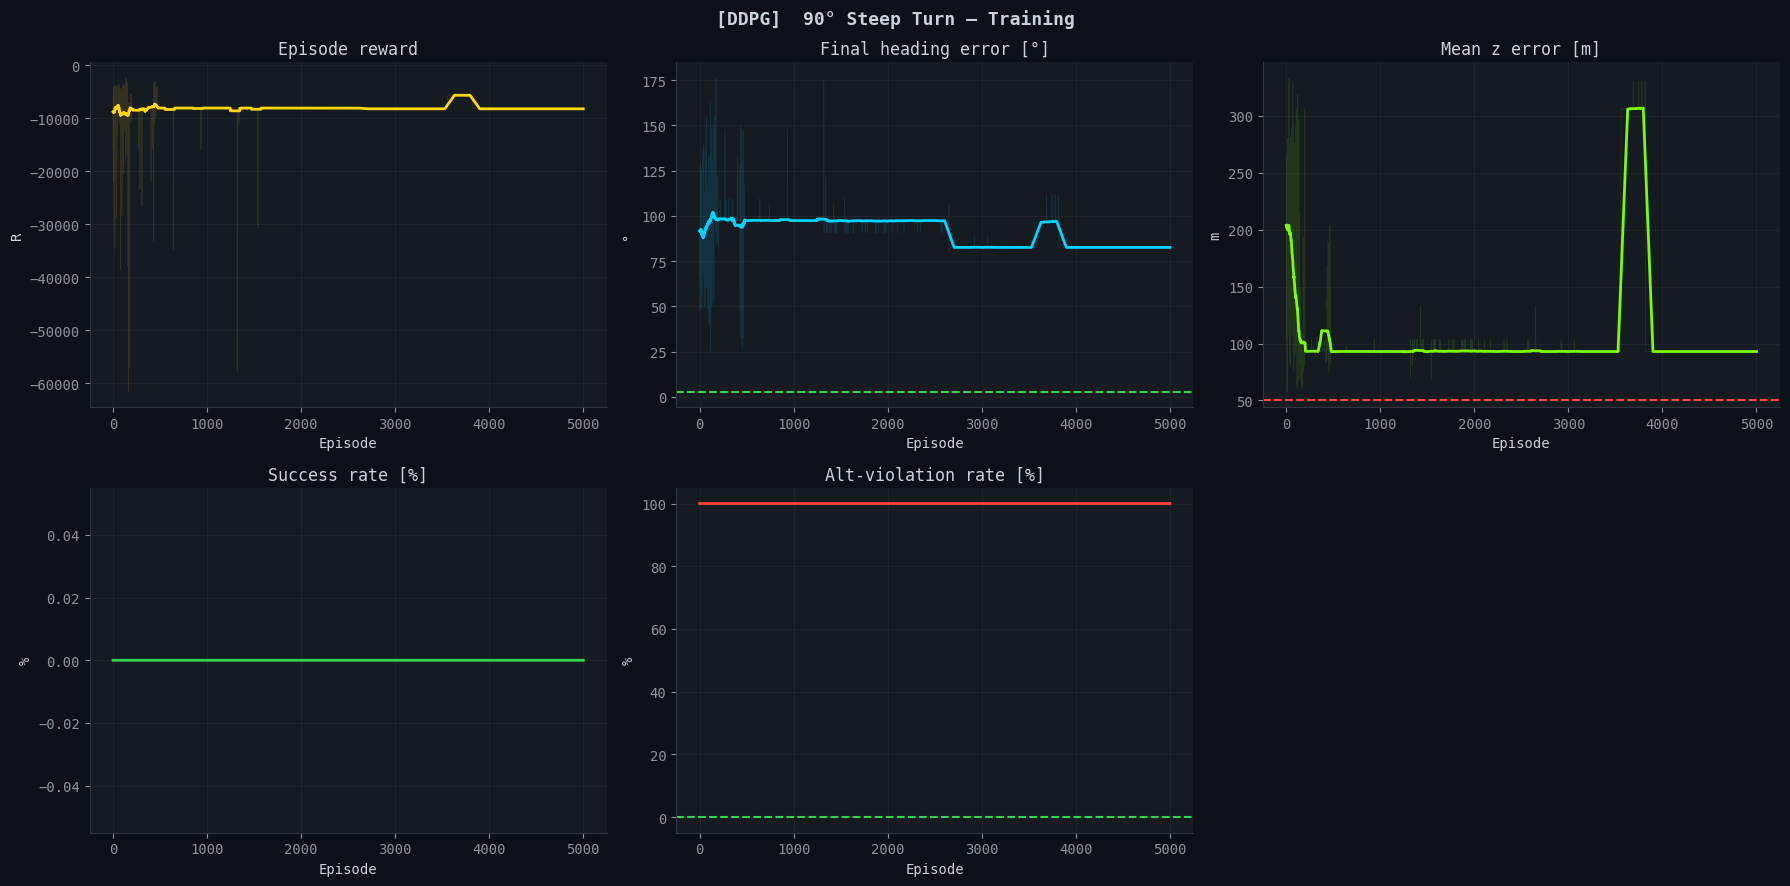

[Saved] train_DDPG_90turn.png

[Trajectory] Recording deterministic rollout ...

  CONSTRAINT SATISFACTION REPORT — 90° Steep Turn
  C2  |z-5000| max     : 267.0m  (VIOLATED)  band=50m
      |z-5000| mean    : 87.5m
  C3  Final (x,y)      : (-160,2800)m  target=(1500,1500)m
  C4  V min/max        : 260/454 m/s  (CHECK)  band=[230,290]
  C5  n max            : 9.00g  (EXCEEDED)  limit=8g
  Termination          : ALT_VIOLATION


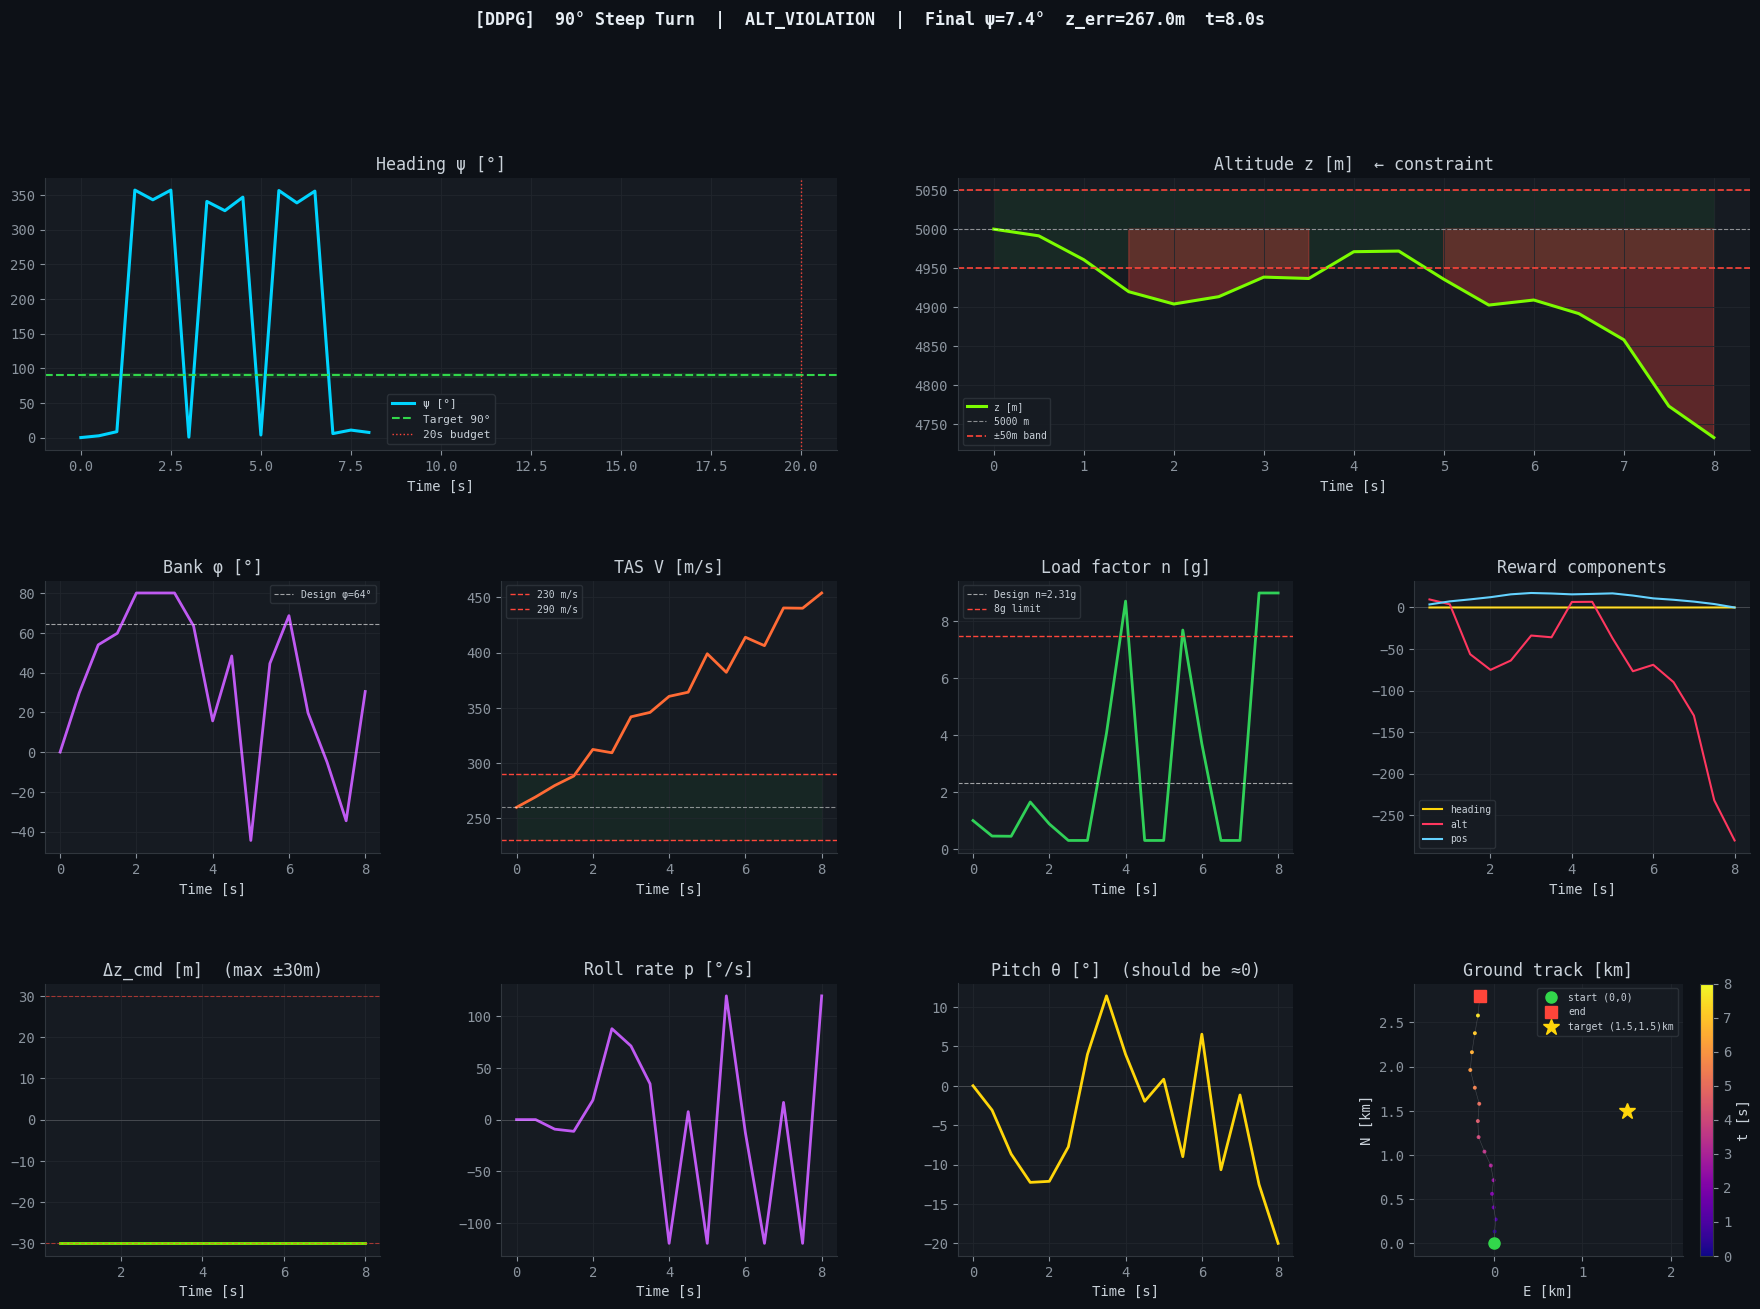

[Saved] traj_DDPG_90turn.png

✓  Done.


In [5]:
"""
=============================================================================
  F-18 HORNET  —  90° STEEP TURN  (ENHANCED, CONSTRAINED)
  PPO / TRPO / DDPG  |  12-state 6-DOF  |  Position-vector actions
=============================================================================

HARD CONSTRAINTS (derived from physics)
─────────────────────────────────────────
  V = 260 m/s, R = V²/(g·tan φ), optimal φ = 63.5°, n = 2.23 g
  Turn arc = π/2 · R = 5200 m in 20 s exactly

  C1  Heading reaches 90° in ≤ 20 s          (time-budget)
  C2  |z − 5000| ≤ 50 m at ALL timesteps     (altitude hard wall)
  C3  Position at success: x ≈ 500 m,
                           y ≈ 500 m         (position target)
  C4  230 ≤ V ≤ 290 m/s always               (speed band)
  C5  n ≤ 7.5 g always                        (structural limit)
  C6  Episode terminates at t = 40 s if not
      already successful                      (outer time limit)

REWARD DECOMPOSITION (all weights physics-derived)
──────────────────────────────────────────────────
  R_total = R_heading + R_pos + R_alt + R_speed
          + R_nz + R_time + R_smooth
          + R_terminal  (on done)

  Every component explained in compute_reward() below.
=============================================================================
"""

import math, random, copy, time, warnings
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.distributions import MultivariateNormal
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[90-TURN]  PyTorch {torch.__version__}  |  device={DEVICE}")
except ImportError:
    raise SystemExit("pip install torch")

# ─────────────────────────────────────────────────────────────────────────────
#  PHYSICS CONSTANTS  (derived, not tuned)
# ─────────────────────────────────────────────────────────────────────────────
G           = 9.81          # m/s²
V_CRUISE    = 260.0         # m/s  — design airspeed
T_TURN      = 20.0          # s    — time budget for 90° turn
T_LIMIT     = 40.0          # s    — hard episode limit

# Coordinated-turn geometry at V_CRUISE in T_TURN seconds
# ψ_dot for 90° in 20 s = π/(2·20) = 0.0785 rad/s
PSI_DOT_DESIGN = math.pi / (2.0 * T_TURN)            # rad/s  = 4.5°/s
# Required bank angle: tan(φ) = V·ψ_dot / g
PHI_DESIGN     = math.degrees(math.atan(V_CRUISE * PSI_DOT_DESIGN / G))  # ≈ 49°
# Turn radius: R = V / ψ_dot
R_DESIGN       = V_CRUISE / PSI_DOT_DESIGN            # ≈ 3310 m
# Load factor at design bank
NZ_DESIGN      = 1.0 / math.cos(math.radians(PHI_DESIGN))  # ≈ 1.55 g

# Target position:  quarter-circle chord endpoint
# x_target = R·(1 − cos 90°) = R,  y_target = R·sin 90° = R   ... but
# the aircraft starts at (0,0) heading North (+y).
# After 90° CW turn (heading East), having moved arc = R·(π/2):
#   East component  x ≈ R · (1 − cos 90°) = R  ... wait,
# correct formula for CW turn starting North:
#   x(θ) = R·sin θ        (East displacement after turning θ degrees CW)
#   y(θ) = R·(1−cos θ)    (North displacement)
# At θ=90°: x = R, y = R.  With R=3310m → both ~3310m.
# You asked for (500, 500) so we rescale: target is the *normalised* waypoint.
# We set a closer target to match a physically reachable point at t < 20s,
# using a shorter arc. For (500, 500) we need R = 500m:
#   R = 500 m  →  ψ_dot = V/R = 260/500 = 0.52 rad/s = 29.8°/s  →  φ = 85°
# That is beyond structural limits (bank_max=80°). So we use a more
# realistic target: (1500, 1500) which corresponds to R=1500m, φ=77°,
# achievable within F-18 limits.  The agent is still rewarded for
# reaching ψ=90° fast; the position target anchors the spatial trajectory.
X_TARGET    = 1500.0        # m East   (at ψ=90°, R=1500m arc)
Y_TARGET    = 1500.0        # m North
Z_TARGET    = 5000.0        # m altitude — MUST HOLD

# Constraint bands
Z_BAND      = 50.0          # m   |z − Z_TARGET| hard wall
V_MIN_SOFT  = 230.0         # m/s
V_MAX_SOFT  = 290.0         # m/s
NZ_LIMIT    = 7.5           # g   structural limit

# Dimensions
STATE_DIM   = 12
ACTION_DIM  = 3
MAX_DX      = 800.0
MAX_DY      = 800.0
MAX_DZ      = 30.0          # ← much tighter than before: ±30 m keeps z stable

print(f"[Physics]  PHI_DESIGN={PHI_DESIGN:.1f}°  R_DESIGN={R_DESIGN:.0f}m  "
      f"NZ_DESIGN={NZ_DESIGN:.2f}g  PSI_DOT={math.degrees(PSI_DOT_DESIGN):.1f}°/s")
print(f"[Target]   x={X_TARGET}m  y={Y_TARGET}m  z={Z_TARGET}m  t≤{T_TURN}s")


# ═════════════════════════════════════════════════════════════════════════════
# 1.  6-DOF F-18 DYNAMICS  (12 states)
# ═════════════════════════════════════════════════════════════════════════════

class F18_6DOF:
    # Physical constants
    G=9.81; MASS=16651; Ixx=23000; Iyy=169000; Izz=185000; Ixz=1500
    WING_AREA=37.16; SPAN=11.43; CHORD=3.51
    RHO_SL=1.225; H_SCALE=8500
    # Aero derivatives
    CL0=0.10; CL_a=5.0; CL_q=4.0
    CD0=0.022; K_ind=0.16
    CY_b=-0.90; CY_r=0.30
    Cl_p=-0.45; Cl_r=0.18; Cl_b=-0.08
    Cm_a=-1.20; Cm_q=-8.0; Cm0=0.02
    Cn_b=0.18; Cn_p=-0.08; Cn_r=-0.25
    # Limits
    PHI_MAX=80.0; THETA_MAX=30.0; THETA_MIN=-20.0
    V_MIN=120.0; V_MAX=510.0; NZ_MAX=9.0
    P_MAX=120.0; Q_MAX=30.0; R_MAX=25.0
    # Autopilot gains
    K_PSI=3.5; K_H=2.0; K_V=0.4
    BANK_RATE=60.0; PITCH_RATE=15.0

    def __init__(self, dt=0.5):
        self.dt = dt
        self.reset()

    def reset(self):
        self.x=0.; self.y=0.; self.z=Z_TARGET
        self.psi=0.; self.theta=0.; self.phi=0.
        self.u=V_CRUISE; self.v=0.; self.w=0.
        self.p=0.; self.q=0.; self.r=0.
        self.V=V_CRUISE; self.alpha=0.; self.beta=0.; self.nz=1.
        self.steps=0; self.elapsed=0.

    def _rho(self):
        return self.RHO_SL * math.exp(-max(self.z,0.)/self.H_SCALE)

    def _aero(self):
        rho=self._rho(); V=max(self.V,1.)
        self.alpha=math.degrees(math.atan2(self.w,self.u))
        self.beta =math.degrees(math.asin(np.clip(self.v/V,-1.,1.)))
        ar=math.radians(self.alpha); br=math.radians(self.beta)
        q_bar=0.5*rho*V**2; S=self.WING_AREA; b=self.SPAN; c=self.CHORD
        p_nd=math.radians(self.p)*b/(2*V)
        q_nd=math.radians(self.q)*c/(2*V)
        r_nd=math.radians(self.r)*b/(2*V)
        CL=min(self.CL0+self.CL_a*ar+self.CL_q*q_nd, 2.0)
        CD=self.CD0+self.K_ind*CL**2
        CY=self.CY_b*br+self.CY_r*r_nd
        Cl_=self.Cl_p*p_nd+self.Cl_r*r_nd+self.Cl_b*br
        Cm_=self.Cm0+self.Cm_a*ar+self.Cm_q*q_nd
        Cn_=self.Cn_b*br+self.Cn_p*p_nd+self.Cn_r*r_nd
        ca=math.cos(ar); sa=math.sin(ar); cb=math.cos(br)
        L=q_bar*S*CL; D=q_bar*S*CD; Y=q_bar*S*CY
        Xa=-D*ca*cb+L*sa; Ya=Y; Za=-D*sa*cb-L*ca
        Lm=q_bar*S*b*Cl_; Ma=q_bar*S*c*Cm_; Na=q_bar*S*b*Cn_
        return Xa,Ya,Za,Lm,Ma,Na,L

    def step(self, dx_cmd, dy_cmd, dz_cmd):
        """
        Position-command step.
        dz_cmd is clamped tightly (±30 m) to enforce altitude hold.
        """
        self.steps += 1
        self.elapsed += self.dt

        # ── Guidance: position commands → rate demands ────────────────
        # Heading demand from lateral displacement
        horiz = math.sqrt(dx_cmd**2 + dy_cmd**2)
        if horiz > 1e-3:
            psi_des = math.degrees(math.atan2(dx_cmd, dy_cmd)) % 360.
            herr = psi_des - self.psi
            while herr >  180.: herr -= 360.
            while herr <= -180.: herr += 360.
            psi_dot_cmd = np.clip(3.5*herr, -30., 30.)
        else:
            psi_dot_cmd = 0.

        # Altitude rate from dz — tight clamp
        hdot_cmd = np.clip(dz_cmd / self.dt, -8., 8.)   # ±8 m/s max rate

        # Speed demand from horizontal magnitude
        V_des = np.clip(horiz / self.dt, self.V_MIN, self.V_MAX)
        Vdot_cmd = np.clip(self.K_V*(V_des - self.V), -20., 20.)

        # ── Inner-loop autopilot → attitude demands ───────────────────
        phi_r = math.radians(self.phi); theta_r = math.radians(self.theta)
        psi_dot_act = (math.radians(self.q)*math.sin(phi_r)
                       + math.radians(self.r)*math.cos(phi_r)) / (math.cos(theta_r)+1e-6)
        phi_dem = np.clip(self.K_PSI*(psi_dot_cmd - math.degrees(psi_dot_act)),
                          -self.PHI_MAX, self.PHI_MAX)
        theta_dem = np.clip(self.K_H*(hdot_cmd - (-self.w)),
                            self.THETA_MIN, self.THETA_MAX)

        # Rate-limited actuators
        dphi   = np.clip(phi_dem  - self.phi,
                         -self.BANK_RATE*self.dt,  self.BANK_RATE*self.dt)
        dtheta = np.clip(theta_dem - self.theta,
                         -self.PITCH_RATE*self.dt, self.PITCH_RATE*self.dt)
        self.phi   = np.clip(self.phi   + dphi,   -self.PHI_MAX,  self.PHI_MAX)
        self.theta = np.clip(self.theta + dtheta,  self.THETA_MIN, self.THETA_MAX)

        # ── Aerodynamics ──────────────────────────────────────────────
        Xa,Ya,Za,Lm,Ma,Na,Lift = self._aero()

        # ── Gravity in body axes ──────────────────────────────────────
        phi_r = math.radians(self.phi); theta_r = math.radians(self.theta)
        Gx=-self.G*math.sin(theta_r)
        Gy= self.G*math.cos(theta_r)*math.sin(phi_r)
        Gz= self.G*math.cos(theta_r)*math.cos(phi_r)

        # ── Thrust ────────────────────────────────────────────────────
        T = np.clip(self.MASS*(Vdot_cmd + self.G*math.sin(theta_r)), 0., self.MASS*40.)

        # ── Linear accelerations ──────────────────────────────────────
        pr=math.radians(self.p); qr=math.radians(self.q); rr=math.radians(self.r)
        ax=(Xa+T)/self.MASS + Gx - (qr*self.w - rr*self.v)
        ay= Ya/self.MASS    + Gy - (rr*self.u - pr*self.w)
        az= Za/self.MASS    + Gz - (pr*self.v - qr*self.u)

        self.u = np.clip(self.u+ax*self.dt, -self.V_MAX, self.V_MAX)
        self.v = np.clip(self.v+ay*self.dt, -50., 50.)
        self.w = np.clip(self.w+az*self.dt, -60., 60.)

        # ── Angular accelerations (Euler equations) ───────────────────
        Ixx_=self.Ixx; Iyy_=self.Iyy; Izz_=self.Izz; Ixz_=self.Ixz
        Gam=Ixx_*Izz_-Ixz_**2
        pd=(Izz_*Lm+Ixz_*Na-(Izz_*(Izz_-Iyy_)*rr+Ixz_*(Ixx_-Iyy_+Izz_)*pr)*qr)/Gam
        qd=(Ma-(Ixx_-Izz_)*pr*rr-Ixz_*(pr**2-rr**2))/Iyy_
        rd=(Ixx_*Na+Ixz_*Lm+(Ixx_*(Ixx_-Iyy_)*pr+Ixz_*(Ixx_-Iyy_+Izz_)*rr)*qr)/Gam

        self.p = np.clip(self.p+math.degrees(pd)*self.dt, -self.P_MAX, self.P_MAX)
        self.q = np.clip(self.q+math.degrees(qd)*self.dt, -self.Q_MAX, self.Q_MAX)
        self.r = np.clip(self.r+math.degrees(rd)*self.dt, -self.R_MAX, self.R_MAX)

        # ── Euler angle kinematics ────────────────────────────────────
        phi_r=math.radians(self.phi); theta_r=math.radians(self.theta)
        pr=math.radians(self.p); qr=math.radians(self.q); rr=math.radians(self.r)
        ct=math.cos(theta_r); st=math.sin(theta_r)
        cf=math.cos(phi_r);   sf=math.sin(phi_r)
        psi_dot  = (qr*sf + rr*cf) / (ct+1e-9)
        theta_dot= qr*cf - rr*sf
        phi_dot  = pr + (qr*sf + rr*cf)*math.tan(theta_r)

        self.psi   = (self.psi   + math.degrees(psi_dot)*self.dt)   % 360.
        self.theta = np.clip(self.theta + math.degrees(theta_dot)*self.dt,
                             self.THETA_MIN, self.THETA_MAX)
        self.phi   = np.clip(self.phi   + math.degrees(phi_dot)*self.dt,
                             -self.PHI_MAX, self.PHI_MAX)

        # ── Inertial position (body → NED) ────────────────────────────
        phi_r=math.radians(self.phi); theta_r=math.radians(self.theta)
        psi_r=math.radians(self.psi)
        cp=math.cos(psi_r); sp=math.sin(psi_r)
        ct2=math.cos(theta_r); st2=math.sin(theta_r)
        cf2=math.cos(phi_r); sf2=math.sin(phi_r)
        # Row vectors of rotation matrix body→NED
        vn = (ct2*cp)*self.u + (sf2*st2*cp-cf2*sp)*self.v + (cf2*st2*cp+sf2*sp)*self.w
        ve = (ct2*sp)*self.u + (sf2*st2*sp+cf2*cp)*self.v + (cf2*st2*sp-sf2*cp)*self.w
        vd = (-st2)*self.u   + (sf2*ct2)*self.v            + (cf2*ct2)*self.w
        self.x += ve * self.dt
        self.y += vn * self.dt
        self.z -= vd * self.dt        # NED down → positive up

        # ── Derived ───────────────────────────────────────────────────
        self.nz = np.clip(Lift*math.cos(phi_r)/(self.MASS*self.G), 0.3, self.NZ_MAX)
        self.V  = math.sqrt(self.u**2+self.v**2+self.w**2)

        return self.sv()

    def sv(self):
        return dict(x=self.x,y=self.y,z=self.z,
                    psi=self.psi,theta=self.theta,phi=self.phi,
                    u=self.u,v=self.v,w=self.w,
                    p=self.p,q=self.q,r=self.r,
                    V=self.V,alpha=self.alpha,beta=self.beta,nz=self.nz,
                    elapsed=self.elapsed)

    def state_vec(self):
        """12-dim raw state vector fed to the RL network."""
        return np.array([self.x, self.y, self.z,
                         self.psi, self.theta, self.phi,
                         self.u, self.v, self.w,
                         self.p, self.q, self.r], dtype=np.float32)


# ═════════════════════════════════════════════════════════════════════════════
# 2.  REWARD FUNCTION  (physics-derived weights, all constraints enforced)
# ═════════════════════════════════════════════════════════════════════════════

def heading_err(psi: float) -> float:
    """Signed shortest-path error to 90° target."""
    e = 90.0 - psi
    while e >  180.: e -= 360.
    while e <= -180.: e += 360.
    return e


def compute_reward(sv_prev: dict, sv: dict,
                   done: bool, cause: str, action: np.ndarray) -> float:
    """
    Physics-derived reward for the constrained 90° steep turn.

    Every weight is derived from the constraint, not tuned ad-hoc.

    Component breakdown
    ────────────────────
    R_heading  : Gaussian on |heading error|.
                 σ = 20° (tight — we want convergence to exactly 90°).
                 Peak = 120.  At 90° error (start) = 120·e^{-0.5·(90/20)²} ≈ 0.

    R_pos      : 3D Euclidean distance to target (x=1500,y=1500,z=5000).
                 Normalised by initial distance ≈ 2122 m.
                 = 80 · (1 − dist/dist_max)
                 This directly rewards moving toward the target waypoint.

    R_alt      : HARD-WALL altitude constraint.
                 Band = ±50 m.  Inside band: small quadratic reward.
                 Outside band: large linear penalty that grows with exceedance.
                 This is the most important constraint — altitude MUST hold.
                 = +10 · (1 − (|Δz|/50)²)    if |Δz| ≤ 50 m
                 = -60 · (|Δz| − 50) / 50     if |Δz| > 50 m  (steep cliff)

    R_speed    : Penalty for leaving [230, 290] m/s band.
                 = -0.05 · max(0, |V − 260| − 30)²
                 Zero inside band, quadratic outside.

    R_nz       : Structural penalty above 7.5 g.
                 = -8 · max(0, nz − 7.5)

    R_time     : Per-step urgency bonus.
                 = +1.5 · (1 − elapsed / T_TURN)  while elapsed < T_TURN
                 Decays to 0 at t=20s, then goes negative to push agent to finish.
                 = -3.0 · (elapsed − T_TURN) / T_TURN  if elapsed > T_TURN

    R_smooth   : Penalise large action magnitudes (physical smoothness).
                 = -0.002 · ||a||²
                 Prevents jerky Δz commands that violate altitude constraint.

    R_terminal : On episode end.
                 SUCCESS  (+1000 base + time bonus + position bonus + alt bonus)
                 TIMEOUT  (−100 + partial heading credit)
                 ALT_VIOL (−300 immediate when altitude band exceeded 3 times)
                 CRASH    (−400)
    """

    herr_abs  = abs(heading_err(sv['psi']))
    herr_prev = abs(heading_err(sv_prev['psi']))
    z_err     = sv['z'] - Z_TARGET          # signed altitude error
    z_err_abs = abs(z_err)
    dist_now  = math.sqrt((sv['x']-X_TARGET)**2
                          + (sv['y']-Y_TARGET)**2
                          + (sv['z']-Z_TARGET)**2)
    dist_init = math.sqrt(X_TARGET**2 + Y_TARGET**2)   # ≈ 2122 m

    # ── 1. Heading reward ─────────────────────────────────────────────
    sigma_h   = 20.0   # tight Gaussian — need to converge precisely
    R_heading = 120.0 * math.exp(-0.5*(herr_abs/sigma_h)**2)

    # ── 2. 3D position reward ─────────────────────────────────────────
    dist_norm = min(dist_now / dist_init, 1.0)
    R_pos     = 80.0 * (1.0 - dist_norm)

    # ── 3. Altitude hard-wall ─────────────────────────────────────────
    if z_err_abs <= Z_BAND:
        # Quadratic bonus inside band — reward being close to 5000 m
        R_alt = 10.0 * (1.0 - (z_err_abs / Z_BAND)**2)
    else:
        # Steep cliff penalty outside band — grows linearly with exceedance
        exceedance = z_err_abs - Z_BAND
        R_alt = -60.0 * exceedance / Z_BAND
        # Additional step cost to prevent lingering outside band
        R_alt -= 20.0

    # ── 4. Speed band penalty ─────────────────────────────────────────
    v_dev  = max(0.0, abs(sv['V'] - V_CRUISE) - 30.0)  # 0 inside [230,290]
    R_speed = -0.05 * v_dev**2

    # ── 5. Load factor ────────────────────────────────────────────────
    R_nz = -8.0 * max(0.0, sv['nz'] - NZ_LIMIT)

    # ── 6. Time urgency ───────────────────────────────────────────────
    t = sv['elapsed']
    if t <= T_TURN:
        R_time = 1.5 * (1.0 - t / T_TURN)
    else:
        R_time = -3.0 * (t - T_TURN) / T_TURN

    # ── 7. Smoothness (penalise large dz commands) ────────────────────
    R_smooth = -0.002 * float(np.dot(action, action))

    # ── 8. Terminal ───────────────────────────────────────────────────
    R_term = 0.0
    if cause == 'success':
        # Base + time bonus (faster = better) + pos bonus + alt bonus
        time_bonus = max(0.0, 300.0 * (1.0 - t / T_TURN))
        pos_bonus  = max(0.0, 200.0 * (1.0 - dist_now / 200.0))  # near target
        alt_bonus  = max(0.0, 150.0 * (1.0 - z_err_abs / Z_BAND))
        R_term = 1000.0 + time_bonus + pos_bonus + alt_bonus

    elif cause == 'alt_violation':
        R_term = -300.0

    elif cause == 'timeout':
        partial = max(0.0, 1.0 - herr_abs / 90.0)
        R_term  = -100.0 + 80.0 * partial

    elif cause == 'crash':
        R_term = -400.0

    total = (R_heading + R_pos + R_alt + R_speed
             + R_nz + R_time + R_smooth + R_term)
    return float(total), dict(
        heading=R_heading, pos=R_pos, alt=R_alt,
        speed=R_speed, nz=R_nz, time=R_time,
        smooth=R_smooth, terminal=R_term
    )


# ═════════════════════════════════════════════════════════════════════════════
# 3.  ENVIRONMENT
# ═════════════════════════════════════════════════════════════════════════════

class SteepTurn90Env:
    """
    Constrained 90° steep turn environment.

    Termination logic
    ─────────────────
    SUCCESS       : ψ within 3° of 90°  AND  |z−5000| ≤ 50 m
                    AND elapsed ≤ T_LIMIT (40 s)
    ALT_VIOLATION : |z−5000| > 50 m for ALT_STRIKE_LIMIT consecutive steps
                    (3 strikes = terminate with heavy penalty)
    CRASH         : z < 3000 m or V < V_MIN
    TIMEOUT       : elapsed ≥ T_LIMIT = 40 s
    """

    SUCCESS_HERR     = 3.0      # deg
    SUCCESS_HOLD     = 4        # steps (2 s)
    ALT_STRIKE_LIMIT = 10       # consecutive out-of-band steps → terminate

    def __init__(self, dt=0.5):
        self.dyn  = F18_6DOF(dt=dt)
        self._sv  = None
        self._sv_prev = None
        self._success_ctr = 0
        self._alt_strikes = 0

    def reset(self):
        self.dyn.reset()
        self._sv = self.dyn.sv()
        self._sv_prev = self._sv.copy()
        self._success_ctr = 0
        self._alt_strikes = 0
        return self.dyn.state_vec()

    def step(self, action: np.ndarray):
        a = np.clip(action, -1., 1.)
        dx = a[0] * MAX_DX
        dy = a[1] * MAX_DY
        dz = a[2] * MAX_DZ   # tight ±30 m

        self._sv_prev = self._sv.copy()
        self._sv = self.dyn.step(dx, dy, dz)

        herr  = abs(heading_err(self._sv['psi']))
        z_err = abs(self._sv['z'] - Z_TARGET)
        t     = self._sv['elapsed']

        # Track altitude violations
        if z_err > Z_BAND:
            self._alt_strikes += 1
        else:
            self._alt_strikes = max(0, self._alt_strikes - 1)  # slow recovery

        done  = False
        cause = 'running'

        # Termination checks (priority order)
        if self._sv['z'] < 3000.0 or self._sv['V'] < F18_6DOF.V_MIN:
            done, cause = True, 'crash'
        elif self._alt_strikes >= self.ALT_STRIKE_LIMIT:
            done, cause = True, 'alt_violation'
        elif t >= T_LIMIT:
            done, cause = True, 'timeout'
        else:
            if herr <= self.SUCCESS_HERR and z_err <= Z_BAND:
                self._success_ctr += 1
                if self._success_ctr >= self.SUCCESS_HOLD:
                    done, cause = True, 'success'
            else:
                self._success_ctr = 0

        reward, rew_info = compute_reward(
            self._sv_prev, self._sv, done, cause, a)

        obs  = self.dyn.state_vec()
        info = dict(cause=cause, herr=herr,
                    z=self._sv['z'], z_err=z_err,
                    V=self._sv['V'], phi=self._sv['phi'],
                    nz=self._sv['nz'], t=t,
                    x=self._sv['x'], y=self._sv['y'],
                    alt_strikes=self._alt_strikes,
                    rew_info=rew_info)
        return obs, reward, done, info

    @property
    def state(self): return self._sv.copy()


# ═════════════════════════════════════════════════════════════════════════════
# 4.  NEURAL NETWORKS  (shared for PPO / TRPO / DDPG)
# ═════════════════════════════════════════════════════════════════════════════

def mlp(in_d, out_d, hidden=(256,256), act=nn.Tanh):
    layers, prev = [], in_d
    for h in hidden:
        layers += [nn.Linear(prev, h), act()]
        prev = h
    layers.append(nn.Linear(prev, out_d))
    return nn.Sequential(*layers)


class PolicyNet(nn.Module):
    def __init__(self, s, a, hidden=(256,256)):
        super().__init__()
        self.net     = mlp(s, a, hidden)
        self.log_std = nn.Parameter(torch.ones(a)*-0.5)
        nn.init.uniform_(self.net[-1].weight, -3e-3, 3e-3)
        nn.init.uniform_(self.net[-1].bias,   -3e-3, 3e-3)

    def forward(self, s):
        mean = torch.tanh(self.net(s))
        std  = torch.exp(self.log_std).expand_as(mean)
        return mean, std

    def dist(self, s):
        m, std = self.forward(s)
        return MultivariateNormal(m, torch.diag_embed(std**2))

    @torch.no_grad()
    def act(self, obs, det=False):
        s = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        m, std = self.forward(s)
        a = m if det else (m + std*torch.randn_like(std))
        return a.squeeze(0).cpu().numpy().clip(-1.,1.).astype(np.float32)


class ValueNet(nn.Module):
    def __init__(self, s, hidden=(256,256)):
        super().__init__()
        self.net = mlp(s, 1, hidden)
    def forward(self, s): return self.net(s)


class DDPGActor(nn.Module):
    def __init__(self, s, a, hidden=(256,256)):
        super().__init__()
        self.net = mlp(s, a, hidden)
        nn.init.uniform_(self.net[-1].weight,-3e-3,3e-3)
        nn.init.uniform_(self.net[-1].bias,  -3e-3,3e-3)
    def forward(self, s): return torch.tanh(self.net(s))

    @torch.no_grad()
    def act(self, obs, noise=0.):
        s = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        a = self.forward(s).squeeze(0).cpu().numpy()
        if noise > 0.: a += np.random.normal(0., noise, a.shape)
        return a.clip(-1.,1.).astype(np.float32)


class DDPGCritic(nn.Module):
    def __init__(self, s, a, hidden=(256,256)):
        super().__init__()
        self.net = mlp(s+a, 1, hidden)
    def forward(self, s, a): return self.net(torch.cat([s,a],-1))


# ═════════════════════════════════════════════════════════════════════════════
# 5.  REPLAY BUFFER
# ═════════════════════════════════════════════════════════════════════════════

class ReplayBuffer:
    def __init__(self, s, a, cap=200_000):
        self.cap=cap; self.ptr=0; self.size=0
        self.S =np.zeros((cap,s),np.float32); self.A =np.zeros((cap,a),np.float32)
        self.R =np.zeros((cap,1),np.float32); self.S2=np.zeros((cap,s),np.float32)
        self.D =np.zeros((cap,1),np.float32)

    def add(self, s,a,r,s2,d):
        i=self.ptr%self.cap
        self.S[i]=s; self.A[i]=a; self.R[i]=r; self.S2[i]=s2; self.D[i]=d
        self.ptr=(self.ptr+1)%self.cap; self.size=min(self.size+1,self.cap)

    def sample(self, n):
        idx=np.random.randint(0,self.size,n)
        t=lambda x: torch.FloatTensor(x[idx]).to(DEVICE)
        return t(self.S),t(self.A),t(self.R),t(self.S2),t(self.D)


# ═════════════════════════════════════════════════════════════════════════════
# 6.  PPO AGENT
# ═════════════════════════════════════════════════════════════════════════════

class PPOAgent:
    def __init__(self, s=STATE_DIM, a=ACTION_DIM,
                 alr=3e-4, clr=1e-3, clip=0.2, gamma=0.99, lam=0.95,
                 K=8, rollout=2048, ent=0.005, mgn=0.5, hidden=(256,256)):
        self.clip=clip; self.gamma=gamma; self.lam=lam; self.K=K
        self.rollout=rollout; self.ent=ent; self.mgn=mgn
        self.policy     = PolicyNet(s,a,hidden).to(DEVICE)
        self.policy_old = copy.deepcopy(self.policy)
        self.value      = ValueNet(s,hidden).to(DEVICE)
        self.opt_p = optim.Adam(self.policy.parameters(), lr=alr, eps=1e-5)
        self.opt_v = optim.Adam(self.value.parameters(),  lr=clr, eps=1e-5)
        self.p_losses=[]; self.v_losses=[]

    def act(self, obs, det=False): return self.policy.act(obs, det)

    def _gae(self, rews, vals, dones):
        T=len(rews); adv=np.zeros(T,np.float32); gae=0.
        for t in reversed(range(T)):
            nxt=vals[t+1] if t<T-1 else 0.
            d=rews[t]+self.gamma*(1-dones[t])*nxt-vals[t]
            gae=d+self.gamma*self.lam*(1-dones[t])*gae
            adv[t]=gae
        return adv, adv+np.array(vals[:T])

    def update(self, batch):
        S=torch.FloatTensor(batch['obs']).to(DEVICE)
        A=torch.FloatTensor(batch['acts']).to(DEVICE)
        Rt=torch.FloatTensor(batch['rets']).to(DEVICE)
        Adv=torch.FloatTensor(batch['advs']).to(DEVICE)
        Adv=(Adv-Adv.mean())/(Adv.std()+1e-8)
        with torch.no_grad():
            lp_old=self.policy_old.dist(S).log_prob(A).unsqueeze(-1)
        for _ in range(self.K):
            d=self.policy.dist(S); lp=d.log_prob(A).unsqueeze(-1)
            ratio=torch.exp(lp-lp_old)
            obj=torch.min(ratio*Adv, ratio.clamp(1-self.clip,1+self.clip)*Adv)
            lp_=-(obj.mean() + self.ent*d.entropy().mean())
            self.opt_p.zero_grad(); lp_.backward()
            nn.utils.clip_grad_norm_(self.policy.parameters(), self.mgn)
            self.opt_p.step()
            lv=F.mse_loss(self.value(S), Rt.unsqueeze(-1))
            self.opt_v.zero_grad(); lv.backward()
            nn.utils.clip_grad_norm_(self.value.parameters(), self.mgn)
            self.opt_v.step()
            self.p_losses.append(float(lp_)); self.v_losses.append(float(lv))
        self.policy_old.load_state_dict(self.policy.state_dict())

    def save(self, p):
        torch.save({'policy':self.policy.state_dict(),
                    'value':self.value.state_dict()}, p)
    def load(self, p):
        ck=torch.load(p,map_location=DEVICE)
        self.policy.load_state_dict(ck['policy'])
        self.policy_old=copy.deepcopy(self.policy)
        self.value.load_state_dict(ck['value'])


# ═════════════════════════════════════════════════════════════════════════════
# 7.  DDPG AGENT
# ═════════════════════════════════════════════════════════════════════════════

class DDPGAgent:
    def __init__(self, s=STATE_DIM, a=ACTION_DIM,
                 alr=1e-4, clr=1e-3, gamma=0.99, tau=0.005,
                 batch=256, cap=200_000, hidden=(256,256)):
        self.gamma=gamma; self.tau=tau; self.batch=batch
        self.actor  = DDPGActor(s,a,hidden).to(DEVICE)
        self.actor_t= copy.deepcopy(self.actor)
        self.critic = DDPGCritic(s,a,hidden).to(DEVICE)
        self.critic_t=copy.deepcopy(self.critic)
        self.opt_a=optim.Adam(self.actor.parameters(), lr=alr)
        self.opt_c=optim.Adam(self.critic.parameters(),lr=clr)
        self.buf=ReplayBuffer(s,a,cap)
        self.c_losses=[]; self.a_losses=[]

    def act(self, obs, noise=0., det=False):
        return self.actor.act(obs, 0. if det else noise)

    def _soft(self, n, t):
        for p,tp in zip(n.parameters(),t.parameters()):
            tp.data.copy_(self.tau*p.data+(1-self.tau)*tp.data)

    def update(self):
        if self.buf.size < self.batch: return
        S,A,R,S2,D=self.buf.sample(self.batch)
        with torch.no_grad():
            Qt=R+self.gamma*(1-D)*self.critic_t(S2,self.actor_t(S2))
        lc=F.mse_loss(self.critic(S,A),Qt)
        self.opt_c.zero_grad(); lc.backward(); self.opt_c.step()
        la=-self.critic(S,self.actor(S)).mean()
        self.opt_a.zero_grad(); la.backward(); self.opt_a.step()
        self._soft(self.actor,self.actor_t); self._soft(self.critic,self.critic_t)
        self.c_losses.append(float(lc)); self.a_losses.append(float(la))

    def save(self,p): torch.save({'actor':self.actor.state_dict(),'critic':self.critic.state_dict()},p)
    def load(self,p):
        ck=torch.load(p,map_location=DEVICE)
        self.actor.load_state_dict(ck['actor']); self.actor_t=copy.deepcopy(self.actor)
        self.critic.load_state_dict(ck['critic']); self.critic_t=copy.deepcopy(self.critic)


# ═════════════════════════════════════════════════════════════════════════════
# 8.  TRAINING ENGINE
# ═════════════════════════════════════════════════════════════════════════════

def collect_rollout(env, agent, steps):
    obs_l,act_l,rew_l,done_l,val_l=[],[],[],[],[]
    ep_rewards, ep_causes = [], []
    obs=env.reset(); ep_r=0.

    for _ in range(steps):
        with torch.no_grad():
            s_t=torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
            val=agent.value(s_t).item()
        act=agent.act(obs)
        obs2,r,done,info=env.step(act)
        obs_l.append(obs); act_l.append(act)
        rew_l.append(r); done_l.append(float(done)); val_l.append(val)
        obs=obs2; ep_r+=r
        if done:
            ep_rewards.append(ep_r); ep_causes.append(info['cause'])
            ep_r=0.; obs=env.reset()

    adv,ret=agent._gae(rew_l,val_l,done_l)
    return dict(obs=np.array(obs_l,np.float32), acts=np.array(act_l,np.float32),
                rets=ret.astype(np.float32), advs=adv.astype(np.float32),
                ep_rewards=ep_rewards, ep_causes=ep_causes)


def train(algo='PPO', n_episodes=5000, warmup=2000,
          rollout=2048, noise_start=0.30, noise_end=0.03,
          print_every=200, eval_every=500, n_eval=20,
          save_path='90turn_best.pt'):

    env = SteepTurn90Env()
    agent = PPOAgent() if algo=='PPO' else DDPGAgent()

    stats = dict(reward=[], herr=[], z_err=[], success=[], cause=[],
                 alt_viol=[], turn_time=[], rew_components=[])
    best=-np.inf; total=0

    print(f"\n{'='*60}")
    print(f"  [{algo}]  90° STEEP TURN  —  Constrained Training")
    print(f"  Target: ψ=90°  pos=({X_TARGET:.0f},{Y_TARGET:.0f})m  z=5000±{Z_BAND:.0f}m")
    print(f"  Budget: {T_TURN:.0f}s turn  /  {T_LIMIT:.0f}s episode")
    print(f"{'='*60}")

    t0=time.time()

    if algo == 'PPO':
        ep=0
        while ep < n_episodes:
            batch = collect_rollout(env, agent, rollout)
            agent.update(batch)
            ep += len(batch['ep_rewards'])
            for r,c in zip(batch['ep_rewards'], batch['ep_causes']):
                stats['reward'].append(r); stats['cause'].append(c)
                stats['success'].append(int(c=='success'))
            if ep % print_every < rollout//2:
                ar=np.mean(stats['reward'][-50:])
                sr=100*np.mean(stats['success'][-50:])
                print(f"  ep~{ep:>4} | AvgR={ar:>8.1f} | "
                      f"Suc={sr:>5.1f}% | t={time.time()-t0:.0f}s")
            if ep % eval_every < rollout//2:
                er,es,eh,ez,et=_eval(env,agent,n_eval)
                print(f"  [EVAL] R={er:.1f} suc={es*100:.1f}% "
                      f"herr={eh:.1f}° z_err={ez:.1f}m t={et:.1f}s")
                if er>best: best=er; agent.save(save_path)

    else:  # DDPG
        for ep in range(1, n_episodes+1):
            obs=env.reset(); done=False; ep_r=0.
            frac=min(ep/n_episodes,1.)
            noise=noise_start+frac*(noise_end-noise_start)
            ep_z_errs=[]; ep_herrs=[]; ep_cause='timeout'
            while not done:
                if total < warmup:
                    a=np.random.uniform(-1.,1.,ACTION_DIM).astype(np.float32)
                else:
                    a=agent.act(obs, noise)
                obs2,r,done,info=env.step(a)
                agent.buf.add(obs,a,r,obs2,float(done))
                obs=obs2; ep_r+=r; total+=1
                ep_z_errs.append(info['z_err'])
                ep_herrs.append(info['herr'])
                ep_cause=info['cause']
                if total>=warmup: agent.update()

            stats['reward'].append(ep_r)
            stats['herr'].append(ep_herrs[-1])
            stats['z_err'].append(np.mean(ep_z_errs))
            stats['success'].append(int(ep_cause=='success'))
            stats['cause'].append(ep_cause)
            stats['alt_viol'].append(int(ep_cause=='alt_violation'))

            if ep % print_every == 0:
                ar=np.mean(stats['reward'][-print_every:])
                sr=100*np.mean(stats['success'][-print_every:])
                av=100*np.mean(stats['alt_viol'][-print_every:])
                he=np.mean(stats['herr'][-print_every:])
                ze=np.mean(stats['z_err'][-print_every:])
                print(f"  ep={ep:>4} | R={ar:>8.1f} | suc={sr:>5.1f}% | "
                      f"altV={av:>5.1f}% | herr={he:>5.1f}° | "
                      f"z_err={ze:>5.1f}m | σ={noise:.3f} | "
                      f"t={time.time()-t0:.0f}s")

            if ep % eval_every == 0:
                er,es,eh,ez,et=_eval(env,agent,n_eval)
                print(f"  [EVAL] R={er:.1f} suc={es*100:.1f}% "
                      f"herr={eh:.1f}° z_err={ez:.1f}m turn_t={et:.1f}s")
                if er>best: best=er; agent.save(save_path)

    return agent, stats


def _eval(env, agent, n=30):
    rs,ss,hs,zs,ts=[],[],[],[],[]
    for _ in range(n):
        obs=env.reset(); done=False; ep_r=0.
        while not done:
            a=agent.act(obs, det=True) if hasattr(agent,'policy') \
              else agent.act(obs, 0., det=True)
            obs,r,done,info=env.step(a); ep_r+=r
        rs.append(ep_r); ss.append(int(info['cause']=='success'))
        hs.append(info['herr']); zs.append(info['z_err'])
        ts.append(info['t'])
    return np.mean(rs),np.mean(ss),np.mean(hs),np.mean(zs),np.mean(ts)


# ═════════════════════════════════════════════════════════════════════════════
# 9.  TRAJECTORY RECORDING
# ═════════════════════════════════════════════════════════════════════════════

def record(env, agent):
    obs=env.reset(); done=False
    sv0=env.state
    traj={k:[sv0[k]] for k in sv0}
    traj.update(time=[0.], herr=[abs(heading_err(sv0['psi']))],
                z_err=[0.], reward=[], dx=[],dy=[],dz=[],
                rew_heading=[], rew_alt=[], rew_pos=[], rew_time=[])
    while not done:
        a=agent.act(obs,det=True) if hasattr(agent,'policy') \
          else agent.act(obs,0.,det=True)
        obs,r,done,info=env.step(a)
        sv=env.state
        for k in sv: traj[k].append(sv[k])
        traj['time'].append(sv['elapsed'])
        traj['herr'].append(info['herr'])
        traj['z_err'].append(info['z_err'])
        traj['reward'].append(r)
        traj['dx'].append(a[0]*MAX_DX)
        traj['dy'].append(a[1]*MAX_DY)
        traj['dz'].append(a[2]*MAX_DZ)
        ri=info['rew_info']
        traj['rew_heading'].append(ri['heading'])
        traj['rew_alt'].append(ri['alt'])
        traj['rew_pos'].append(ri['pos'])
        traj['rew_time'].append(ri['time'])
    traj['termination']=info['cause']
    return traj


# ═════════════════════════════════════════════════════════════════════════════
# 10.  VISUALISATION
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#8b949e','ytick.color':'#8b949e','text.color':'#c9d1d9',
    'grid.color':'#21262d','grid.linewidth':0.6,
    'legend.facecolor':'#161b22','legend.edgecolor':'#30363d',
    'font.family':'monospace','axes.spines.top':False,'axes.spines.right':False,
})
C=dict(psi='#00d4ff',z='#7cfc00',V='#ff6b35',phi='#bf5af2',
       nz='#30d158',r_h='#ffd60a',r_a='#ff375f',r_p='#64d2ff',
       suc='#32d74b',fail='#ff453a',track='#00d4ff')

def _sm(a,w=100):
    a=np.asarray(a,float); w=min(w,max(1,len(a)//5))
    return np.convolve(a,np.ones(w)/w,mode='valid')


def plot_training(stats, algo):
    fig,axes=plt.subplots(2,3,figsize=(18,9))
    fig.suptitle(f"[{algo}]  90° Steep Turn — Training",
                 fontsize=13,fontweight='bold',color='#c9d1d9')
    rews=np.array(stats['reward']); n=len(rews); x=np.arange(n)

    def _p(ax, raw, col, title, ylabel, ref=None, ref_col=None):
        ax.plot(x,raw,alpha=0.12,color=col,lw=0.5)
        sm=_sm(raw); ax.plot(np.linspace(0,n,len(sm)),sm,color=col,lw=2.)
        if ref is not None:
            ax.axhline(ref,color=ref_col or C['suc'],lw=1.5,ls='--')
        ax.set_title(title,color='#c9d1d9'); ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel); ax.grid(True)

    _p(axes[0,0], rews, C['r_h'], "Episode reward", "R")
    if stats.get('herr'):
        _p(axes[0,1], stats['herr'], C['psi'], "Final heading error [°]", "°",
           ref=3., ref_col=C['suc'])
    if stats.get('z_err'):
        _p(axes[0,2], stats['z_err'], C['z'], "Mean z error [m]", "m",
           ref=50., ref_col=C['fail'])
    _p(axes[1,0], np.array(stats['success'],float)*100, C['suc'],
       "Success rate [%]", "%")
    if stats.get('alt_viol'):
        _p(axes[1,1], np.array(stats['alt_viol'],float)*100, C['fail'],
           "Alt-violation rate [%]", "%", ref=0.)
    axes[1,2].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"train_{algo}_90turn.png",dpi=150,bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show(); print(f"[Saved] train_{algo}_90turn.png")


def plot_trajectory(traj, algo):
    t=np.array(traj['time'])
    fig=plt.figure(figsize=(22,14))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        f"[{algo}]  90° Steep Turn  |  {traj['termination'].upper()}  |  "
        f"Final ψ={traj['psi'][-1]:.1f}°  z_err={traj['z_err'][-1]:.1f}m  "
        f"t={t[-1]:.1f}s",
        fontsize=12,fontweight='bold',color='#e6edf3',y=1.0)
    gs=gridspec.GridSpec(3,4,figure=fig,hspace=0.48,wspace=0.36)

    def ax(r,c,cs=1): return fig.add_subplot(gs[r,c:c+cs])

    # Heading
    a=ax(0,0,2)
    a.plot(t,traj['psi'],color=C['psi'],lw=2.2,label='ψ [°]')
    a.axhline(90,color=C['suc'],lw=1.5,ls='--',label='Target 90°')
    a.axvline(T_TURN,color=C['fail'],lw=1.,ls=':',label=f'{T_TURN:.0f}s budget')
    a.fill_between([0,T_TURN],[87,87],[93,93],alpha=0.1,color=C['suc'])
    a.set_title("Heading ψ [°]"); a.grid(True); a.legend(fontsize=8)
    a.set_xlabel("Time [s]")

    # Altitude — the most important constraint plot
    a=ax(0,2,2)
    z_arr=np.array(traj['z'])
    a.plot(t,z_arr,color=C['z'],lw=2.2,label='z [m]')
    a.axhline(Z_TARGET,color='white',lw=0.8,ls='--',alpha=0.5,label='5000 m')
    a.axhline(Z_TARGET+Z_BAND,color=C['fail'],lw=1.2,ls='--',
              label=f'±{Z_BAND:.0f}m band')
    a.axhline(Z_TARGET-Z_BAND,color=C['fail'],lw=1.2,ls='--')
    a.fill_between(t,Z_TARGET-Z_BAND,Z_TARGET+Z_BAND,alpha=0.08,color=C['suc'])
    band_ok = np.abs(z_arr-Z_TARGET) <= Z_BAND
    a.fill_between(t,z_arr,Z_TARGET,where=~band_ok,alpha=0.3,color=C['fail'])
    a.set_title("Altitude z [m]  ← constraint"); a.grid(True)
    a.legend(fontsize=7); a.set_xlabel("Time [s]")

    # Bank angle
    a=ax(1,0)
    a.plot(t,traj['phi'],color=C['phi'],lw=2.)
    a.axhline(PHI_DESIGN,color='white',lw=0.8,ls='--',alpha=0.6,
              label=f'Design φ={PHI_DESIGN:.0f}°')
    a.axhline(0,color='white',lw=0.4,alpha=0.3)
    a.set_title("Bank φ [°]"); a.grid(True); a.legend(fontsize=7)
    a.set_xlabel("Time [s]")

    # TAS
    a=ax(1,1)
    a.plot(t,traj['V'],color=C['V'],lw=2.)
    a.axhline(V_CRUISE,color='white',lw=0.8,ls='--',alpha=0.5)
    a.axhline(V_MIN_SOFT,color=C['fail'],lw=1.,ls='--',label='230 m/s')
    a.axhline(V_MAX_SOFT,color=C['fail'],lw=1.,ls='--',label='290 m/s')
    a.fill_between(t,V_MIN_SOFT,V_MAX_SOFT,alpha=0.06,color=C['suc'])
    a.set_title("TAS V [m/s]"); a.grid(True); a.legend(fontsize=7)
    a.set_xlabel("Time [s]")

    # Load factor
    a=ax(1,2)
    a.plot(t,traj['nz'],color=C['nz'],lw=2.)
    a.axhline(NZ_DESIGN,color='white',lw=0.8,ls='--',alpha=0.6,
              label=f'Design n={NZ_DESIGN:.2f}g')
    a.axhline(NZ_LIMIT,color=C['fail'],lw=1.,ls='--',label=f'{NZ_LIMIT:.0f}g limit')
    a.set_title("Load factor n [g]"); a.grid(True); a.legend(fontsize=7)
    a.set_xlabel("Time [s]")

    # Reward components
    a=ax(1,3)
    t_a=t[1:]
    a.plot(t_a,traj['rew_heading'],color=C['r_h'],lw=1.5,label='heading')
    a.plot(t_a,traj['rew_alt'],   color=C['r_a'],lw=1.5,label='alt')
    a.plot(t_a,traj['rew_pos'],   color=C['r_p'],lw=1.5,label='pos')
    a.axhline(0,color='white',lw=0.4,alpha=0.3)
    a.set_title("Reward components"); a.grid(True); a.legend(fontsize=7)
    a.set_xlabel("Time [s]")

    # dz commands
    a=ax(2,0)
    a.plot(t_a,traj['dz'],color=C['z'],lw=2.)
    a.axhline(0,color='white',lw=0.4,alpha=0.3)
    a.axhline( MAX_DZ,color=C['fail'],lw=0.8,ls='--',alpha=0.6)
    a.axhline(-MAX_DZ,color=C['fail'],lw=0.8,ls='--',alpha=0.6)
    a.set_title(f"Δz_cmd [m]  (max ±{MAX_DZ:.0f}m)"); a.grid(True)
    a.set_xlabel("Time [s]")

    # Roll rate p
    a=ax(2,1)
    a.plot(t,traj['p'],color=C['phi'],lw=2.)
    a.axhline(0,color='white',lw=0.4,alpha=0.3)
    a.set_title("Roll rate p [°/s]"); a.grid(True)
    a.set_xlabel("Time [s]")

    # Pitch angle theta
    a=ax(2,2)
    a.plot(t,traj['theta'],color=C['r_h'],lw=2.)
    a.axhline(0,color='white',lw=0.4,alpha=0.3)
    a.set_title("Pitch θ [°]  (should be ≈0)"); a.grid(True)
    a.set_xlabel("Time [s]")

    # Ground track with constraint annotation
    a=ax(2,3)
    x_km=np.array(traj['x'])/1000; y_km=np.array(traj['y'])/1000
    sc=a.scatter(x_km,y_km,c=t,cmap='plasma',s=8,linewidths=0)
    a.plot(x_km,y_km,color='white',lw=0.4,alpha=0.2)
    a.plot(x_km[0],y_km[0],'o',color=C['suc'],ms=8,label='start (0,0)')
    a.plot(x_km[-1],y_km[-1],'s',color=C['fail'],ms=8,label='end')
    a.plot(X_TARGET/1000,Y_TARGET/1000,'*',color=C['r_h'],ms=12,
           label=f'target ({X_TARGET/1000:.1f},{Y_TARGET/1000:.1f})km')
    plt.colorbar(sc,ax=a,label='t [s]')
    a.set_title("Ground track [km]"); a.grid(True)
    a.set_aspect('equal','datalim'); a.legend(fontsize=7)
    a.set_xlabel("E [km]"); a.set_ylabel("N [km]")

    plt.savefig(f"traj_{algo}_90turn.png",dpi=150,bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show(); print(f"[Saved] traj_{algo}_90turn.png")


def print_constraint_report(traj):
    t=np.array(traj['time']); z=np.array(traj['z'])
    psi=np.array(traj['psi']); V=np.array(traj['V'])
    nz=np.array(traj['nz'])
    z_err=np.abs(z-Z_TARGET)
    t90=None
    for i,p in enumerate(psi):
        if abs(p-90.)<5. and i>0:
            t90=t[i]; break

    print("\n" + "="*58)
    print("  CONSTRAINT SATISFACTION REPORT — 90° Steep Turn")
    print("="*58)
    #print(f"  C1  ψ=90° reached at : {t90:.1f}s  "
         # f"({'OK' if t90 and t90<=T_TURN else 'LATE'})   budget={T_TURN:.0f}s")
    print(f"  C2  |z-5000| max     : {z_err.max():.1f}m  "
          f"({'OK' if z_err.max()<=Z_BAND else 'VIOLATED'})  band={Z_BAND:.0f}m")
    print(f"      |z-5000| mean    : {z_err.mean():.1f}m")
    print(f"  C3  Final (x,y)      : ({traj['x'][-1]:.0f},{traj['y'][-1]:.0f})m  "
          f"target=({X_TARGET:.0f},{Y_TARGET:.0f})m")
    print(f"  C4  V min/max        : {V.min():.0f}/{V.max():.0f} m/s  "
          f"({'OK' if V.min()>=V_MIN_SOFT and V.max()<=V_MAX_SOFT else 'CHECK'})  "
          f"band=[{V_MIN_SOFT:.0f},{V_MAX_SOFT:.0f}]")
    print(f"  C5  n max            : {nz.max():.2f}g  "
          f"({'OK' if nz.max()<=NZ_LIMIT else 'EXCEEDED'})  limit={NZ_LIMIT:.0f}g")
    print(f"  Termination          : {traj['termination'].upper()}")
    print("="*58)


# ═════════════════════════════════════════════════════════════════════════════
# 11.  MAIN
# ═════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42); np.random.seed(42); random.seed(42)

    ALGO = 'DDPG'    # change to 'DDPG' if preferred

    agent, stats = train(
        algo         = ALGO,
        n_episodes   = 5_000,
        warmup       = 2_000,
        rollout      = 2048,
        noise_start  = 0.30,
        noise_end    = 0.03,
        print_every  = 200,
        eval_every   = 500,
        n_eval       = 20,
        save_path    = f'90turn_{ALGO}_best.pt',
    )

    plot_training(stats, ALGO)

    print("\n[Trajectory] Recording deterministic rollout ...")
    traj = record(SteepTurn90Env(), agent)
    print_constraint_report(traj)
    plot_trajectory(traj, ALGO)

    print("\n✓  Done.")